In [1]:
# -----------------------------------------------------------------------------
#  I.   Nombre completo del estudiante : Ricardo González Manzano
#  II.  Grupo                          : 5AV1
#  III. Carrera                        : Licenciatura en Ciencia de Datos
#  IV.  Fecha de última modificación   : 06/10/2026
# -----------------------------------------------------------------------------
#  V.   DESCRIPCIÓN DE LA FUNCIONALIDAD
#  Sección G. Repite el análisis exploratorio de la Sección A sobre el
#  dataset resultante de todo el proceso (data/processed/
#  dataset_final_procesado.csv, generado por la Sección F):
#    32. Análisis numérico: total de observaciones y nulos, dimensiones
#        cuantitativas guardadas como texto o con unidades, inconsistencias
#        en las cualitativas, clases y frecuencias, y estadística descriptiva
#        (media, mediana, moda, desviación estándar, varianza, mínimo, máximo,
#        rango y cuartiles).
#    33. Análisis gráfico: distribuciones cuantitativas, pairplot, mapa de
#        calor de correlación, distribuciones cualitativas, comparación de
#        cada categórica contra Precio_Venta y análisis de las dimensiones
#        nuevas (Antigüedad, Marca, Modelo, Precio_por_Km y Vehiculo_Antiguo).
#  Las columnas codificadas en la Sección E (binarias, one-hot y de
#  frecuencia) son códigos y no medidas, por lo que no se tratan como
#  cuantitativas (observación 11).
#
#  Sección H. Atiende el inciso 34: contrasta el EDA inicial (datos
#  originales, Sección A) con el EDA final (Sección G), identifica las
#  diferencias, argumenta sus causas a partir de lo realizado en cada etapa
#  (B a F) y presenta conclusiones sustentadas en estadísticos y gráficas.
#  Compara: observaciones y dimensiones por etapa, calidad de los datos,
#  estadísticos de CarDekho, dimensiones de UCI antes y después de
#  integrarlas, clases, forma del precio, correlaciones con el precio y el
#  aporte de las dimensiones nuevas.
#
#  Ningún dataset se modifica. Las figuras se guardan en figuras/ con los
#  prefijos "figura_G" y "figura_H".
#
#  PARÁMETROS DE EJECUCIÓN
#  El notebook no recibe parámetros. Requisitos para su correcta ejecución:
#    - Abrirse desde la carpeta Practica01 (usa las rutas relativas src/,
#      data/processed/ y figuras/).
#    - Haber ejecutado antes las Secciones B a F, que generan los archivos
#      de data/processed/.
#    - Conexión a internet la primera vez: la Sección H descarga los datos
#      originales con hm.cargar_cardekho() y hm.cargar_uci().
#    - Tener instaladas las dependencias de src/requirements.txt.
#
#  FUNCIONES UTILIZADAS
#  Todas están definidas y documentadas en src/eda.py y src/homologacion.py;
#  este notebook no define funciones nuevas:
#  - hm.cargar_cardekho() -> pd.DataFrame / hm.cargar_uci() -> pd.DataFrame
#        Descarga de los datos originales (Sección H).
#  - configurar_estilo() -> None
#        Estilo común de las gráficas.
#  - resumen_nulos(df: pd.DataFrame) -> pd.DataFrame
#        Observaciones, nulos, porcentaje de nulos y nulos ocultos.
#  - detectar_texto_cuantitativo(df: pd.DataFrame) -> pd.DataFrame
#        Diagnóstico de dimensiones guardadas como texto o con unidades.
#  - inconsistencias_cualitativas(df: pd.DataFrame, columnas: list)
#        -> pd.DataFrame
#        Mayúsculas, espacios, separadores y nombres truncados.
#  - distribucion_clases(serie: pd.Series) -> pd.DataFrame
#        Cantidad y porcentaje de observaciones por clase.
#  - estadisticos_cuantitativos(df: pd.DataFrame, columnas: list)
#        -> pd.DataFrame
#        Media, mediana, moda, desv. estándar, varianza, mín, máx, rango,
#        cuartiles e IQR.
#  - graficar_distribuciones_cuantitativas(df, columnas, unidades, titulo,
#        archivo) -> Figure
#  - graficar_pairplot(df, columnas, titulo, archivo, altura) -> PairGrid
#  - graficar_mapa_calor(df, columnas, titulo, archivo) -> pd.DataFrame
#  - graficar_distribuciones_cualitativas(df, columnas, titulo, archivo,
#        max_clases) -> Figure
#  - precio_por_categoria(df, categoria, precio) -> pd.DataFrame
#  - graficar_categorias_vs_precio(df, columnas, precio, unidad_precio,
#        titulo, archivo, max_clases) -> Figure
#  - graficar_nuevas_caracteristicas(df, titulo, archivo, umbral) -> Figure
#        Análisis gráfico de Antigüedad, Precio_por_Km y Vehiculo_Antiguo.
#  - comparar_estadisticos(est_antes, est_despues, pares, medidas)
#        -> pd.DataFrame
#        Medidas antes y después, con diferencia y cambio %.
#  - comparar_clases(antes: pd.Series, despues: pd.Series) -> pd.DataFrame
#        Observaciones y porcentaje de cada clase antes y después.
#  - graficar_etapas(tabla, titulo, archivo) -> Figure
#        Observaciones y dimensiones por etapa.
#  - graficar_comparacion_correlaciones(tabla, titulo, archivo) -> Figure
#        Correlación con el precio al inicio y al final.
# =============================================================================

# Sección G — Análisis exploratorio de datos posterior al procesamiento (incisos 32 y 33)
**Responsable:** Ricardo

**Propósito:** repetir el análisis exploratorio de la Sección A sobre el dataset final, para obtener los resultados que la Sección H compara con los iniciales.

**Insumo:** `data/processed/dataset_final_procesado.csv` (resultado de la Sección F, después de la integración B, el filtrado C, la limpieza D, la transformación E y la ingeniería de características F).

**¿Qué hace esta celda?** Prepara las herramientas de las Secciones G y H.
- `pandas` maneja las tablas y `matplotlib` muestra las figuras.
- `homologacion` (alias `hm`) es el módulo del equipo que descarga los datos originales; solo lo usa la Sección H.
- `eda` es el módulo de la Sección A: se reutilizan las mismas funciones para que el análisis final sea comparable con el inicial y las figuras tengan el mismo estilo.
- Se configura cómo se muestran las tablas y se crea la carpeta `figuras/`.

In [2]:
# =====================================================================
# Propósito: importar librerías, el módulo de carga (homologacion.py) y
#            las funciones del EDA (eda.py), y configurar cómo se
#            muestran las tablas y las gráficas.
# Entrada:   ninguna.
# Salida:    entorno listo y carpeta "figuras/" creada.
# =====================================================================
import os                          # Rutas y creación de carpetas
import sys                         # Agregar "src" a las rutas de búsqueda de módulos

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display  # Mostrar varias tablas en una misma celda

sys.path.append("src")
import homologacion as hm
from eda import (CARPETA_FIGURAS, configurar_estilo, resumen_nulos,
                 detectar_texto_cuantitativo, inconsistencias_cualitativas,
                 distribucion_clases, estadisticos_cuantitativos,
                 graficar_distribuciones_cuantitativas, graficar_pairplot,
                 graficar_mapa_calor, graficar_distribuciones_cualitativas,
                 precio_por_categoria, graficar_categorias_vs_precio,
                 graficar_nuevas_caracteristicas, comparar_estadisticos,
                 comparar_clases, graficar_etapas, graficar_comparacion_correlaciones)

# Tablas: mostrar todas las columnas y hasta 200 filas sin recortarlas.
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.float_format", "{:,.3f}".format)

configurar_estilo()
os.makedirs(CARPETA_FIGURAS, exist_ok=True)

## Carga del dataset final

**¿Qué hace esta celda?** Lee el dataset final y muestra su tamaño y sus primeras filas. En este notebook el dataset no se modifica.

In [3]:
# =====================================================================
# Propósito: cargar el dataset final y mostrar sus dimensiones.
# Entrada:   data/processed/dataset_final_procesado.csv (Sección F).
# Salida:    DataFrame df (no se modifica en este notebook).
# =====================================================================
RUTA_FINAL = "data/processed/dataset_final_procesado.csv"
df = pd.read_csv(RUTA_FINAL)
print(f"Dataset final: {df.shape[0]:,} registros × {df.shape[1]} dimensiones")
df.head(5)

Dataset final: 15,244 registros × 73 dimensiones


,Nombre,Modelo,Kilómetros,Tipo_Vendedor,Combustible,Transmisión,Millaje,Motor,Potencia_Máxima,Asientos,Precio_Venta,Año,Marca,Marca_Homologada,Millaje_Carretera,Millaje_Ciudad,RPM_Maximas,Caballos_Fuerza,Relacion_Compresion,Carrera_Piston,Diametro_Cilindro,Tamano_Motor,Num_Cilindros,Peso_Vacio,Altura,Ancho,Longitud,Distancia_Ejes,Num_Puertas,Sistema_Combustible,Tipo_Motor,Ubicacion_Motor,Traccion,Carroceria,Aspiracion,Tiene_Datos_UCI,Precio_Venta_Lakhs,Precio_Venta_Log,Transmision_Automatica,Combustible_CNG,Combustible_Diesel,Combustible_Electric,Combustible_LPG,Combustible_Petrol,Tipo_Vendedor_Dealer,Tipo_Vendedor_Individual,Tipo_Vendedor_Trustmark Dealer,Carroceria_Desconocido,Carroceria_hardtop,Carroceria_hatchback,Carroceria_sedan,Traccion_Desconocido,Traccion_fwd,Traccion_rwd,Aspiracion_Desconocido,Aspiracion_std,Tipo_Motor_Desconocido,Tipo_Motor_dohc,Tipo_Motor_ohc,Tipo_Motor_ohcf,Ubicacion_Motor_Desconocido,Ubicacion_Motor_front,Ubicacion_Motor_rear,Sistema_Combustible_1bbl,Sistema_Combustible_2bbl,Sistema_Combustible_Desconocido,Sistema_Combustible_idi,Sistema_Combustible_mpfi,Marca_Homologada_Frec,Modelo_Frec,Antigüedad,Precio_por_Km,Vehiculo_Antiguo
0,Maruti Alto,Alto,120000,Individual,Petrol,Manual,20,796,46,5,120000,2012,Maruti,maruti,13.990,11.691,"5,154.167",81.083,9.215,87.186,80.591,"1,946.988",4.083,"1,107.261","1,364.536","1,653.302","4,367.133","2,479.252",3.125,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,0,1.200,11.695,0,0,0,0,0,1,0,1,0,1,0,0,0,1,0,0,1,0,1,0,0,0,1,0,0,0,0,1,0,0,0.324,0.050,9,1.000,0
1,Hyundai Grand,Grand,20000,Individual,Petrol,Manual,19,1197,82,5,550000,2016,Hyundai,hyundai,13.990,11.691,"5,154.167",81.083,9.215,87.186,80.591,"1,946.988",4.083,"1,107.261","1,364.536","1,653.302","4,367.133","2,479.252",3.125,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,0,5.500,13.218,0,0,0,0,0,1,0,1,0,1,0,0,0,1,0,0,1,0,1,0,0,0,1,0,0,0,0,1,0,0,0.194,0.037,5,27.500,0
2,Hyundai i20,i20,60000,Individual,Petrol,Manual,17,1197,80,5,215000,2010,Hyundai,hyundai,13.990,11.691,"5,154.167",81.083,9.215,87.186,80.591,"1,946.988",4.083,"1,107.261","1,364.536","1,653.302","4,367.133","2,479.252",3.125,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,0,2.150,12.278,0,0,0,0,0,1,0,1,0,1,0,0,0,1,0,0,1,0,1,0,0,0,1,0,0,0,0,1,0,0,0.194,0.059,11,3.583,1
3,Maruti Alto,Alto,37000,Individual,Petrol,Manual,21,998,67,5,226000,2012,Maruti,maruti,13.990,11.691,"5,154.167",81.083,9.215,87.186,80.591,"1,946.988",4.083,"1,107.261","1,364.536","1,653.302","4,367.133","2,479.252",3.125,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,0,2.260,12.328,0,0,0,0,0,1,0,1,0,1,0,0,0,1,0,0,1,0,1,0,0,0,1,0,0,0,0,1,0,0,0.324,0.050,9,6.108,0
4,Ford Ecosport,Ecosport,30000,Dealer,Diesel,Manual,23,1498,99,5,570000,2015,Ford,ford,13.990,11.691,"5,154.167",81.083,9.215,87.186,80.591,"1,946.988",4.083,"1,107.261","1,364.536","1,653.302","4,367.133","2,479.252",3.125,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,0,5.700,13.253,0,0,1,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0,1,0,0,0,1,0,0,0,0,1,0,0,0.051,0.024,6,19.000,0


**¿Qué hace esta celda?** Agrupa las 73 dimensiones según su origen y su naturaleza.
**¿Para qué?** No todas deben analizarse igual:
- **Cuantitativas de CarDekho:** medidas originales del vehículo (algunas redondeadas en la Sección E).
- **Precio transformado (Sección E):** `Precio_Venta_Lakhs` y `Precio_Venta_Log`.
- **Cuantitativas nuevas (Sección F):** `Antigüedad` y `Precio_por_Km`.
- **Cuantitativas de UCI:** promedios por fabricante agregados en la integración y convertidos a unidades métricas. Solo el 29 % de los registros tiene datos reales de UCI; el resto se imputó con la mediana en la Sección D.
- **Cualitativas:** las dimensiones de texto, más `Vehiculo_Antiguo` y `Tiene_Datos_UCI`, que son indicadores 0/1 y se analizan por clase.
- **Codificadas (Sección E):** columnas binarias, one-hot y de frecuencia. Son códigos de una categoría, no medidas, así que no entran en los estadísticos ni en las correlaciones (observación 11).

El `assert` comprueba que cada dimensión quedó en exactamente un grupo.

In [4]:
# =====================================================================
# Propósito: clasificar las 73 dimensiones del dataset final por grupo.
# Entrada:   df.
# Salida:    listas de dimensiones por grupo y tabla de resumen.
# =====================================================================
CUANT_CARDEKHO = ["Kilómetros", "Millaje", "Motor", "Potencia_Máxima", "Asientos", "Precio_Venta", "Año"]
CUANT_PRECIO = ["Precio_Venta_Lakhs", "Precio_Venta_Log"]
CUANT_NUEVAS = ["Antigüedad", "Precio_por_Km"]
CUANT_UCI = ["Millaje_Carretera", "Millaje_Ciudad", "RPM_Maximas", "Caballos_Fuerza",
             "Relacion_Compresion", "Carrera_Piston", "Diametro_Cilindro", "Tamano_Motor",
             "Num_Cilindros", "Peso_Vacio", "Altura", "Ancho", "Longitud", "Distancia_Ejes",
             "Num_Puertas"]
CUALITATIVAS = ["Nombre", "Modelo", "Marca", "Marca_Homologada", "Tipo_Vendedor", "Combustible",
                "Transmisión", "Carroceria", "Traccion", "Aspiracion", "Tipo_Motor",
                "Ubicacion_Motor", "Sistema_Combustible", "Vehiculo_Antiguo", "Tiene_Datos_UCI"]
# Codificadas: todo lo que no está en los grupos anteriores (Sección E, inciso 26).
CODIFICADAS = [c for c in df.columns
               if c not in CUANT_CARDEKHO + CUANT_PRECIO + CUANT_NUEVAS + CUANT_UCI + CUALITATIVAS]

grupos = {"Cuantitativa de CarDekho": CUANT_CARDEKHO, "Precio transformado": CUANT_PRECIO,
          "Cuantitativa nueva (Sección F)": CUANT_NUEVAS, "Cuantitativa de UCI": CUANT_UCI,
          "Cualitativa": CUALITATIVAS, "Codificada (binaria, one-hot o frecuencia)": CODIFICADAS}
clasificacion = pd.DataFrame([(col, grupo, str(df[col].dtype))
                              for grupo, cols in grupos.items() for col in cols],
                             columns=["Dimensión", "Grupo", "Tipo de dato"])
# Comprobación: cada dimensión pertenece exactamente a un grupo.
assert sorted(clasificacion["Dimensión"]) == sorted(df.columns)

# Listas que se usan en el resto del notebook.
CUANT_PRINCIPALES = CUANT_CARDEKHO + CUANT_PRECIO + CUANT_NUEVAS
CUALI_TEXTO = [c for c in CUALITATIVAS if not pd.api.types.is_numeric_dtype(df[c])]
# Marca_Homologada tiene las mismas 30 clases que Marca, escritas en minúsculas;
# en las gráficas se omite para no repetir la misma información.
CUALI_GRAFICAS = [c for c in CUALITATIVAS if c != "Marca_Homologada"]

display(clasificacion.groupby("Grupo", sort=False).size().rename("Dimensiones").to_frame())
print("Codificadas:", CODIFICADAS)

,Dimensiones
Grupo,
Cuantitativa de CarDekho,7
Precio transformado,2
Cuantitativa nueva (Sección F),2
Cuantitativa de UCI,15
Cualitativa,15
"Codificada (binaria, one-hot o frecuencia)",32


Codificadas: ['Transmision_Automatica', 'Combustible_CNG', 'Combustible_Diesel', 'Combustible_Electric', 'Combustible_LPG', 'Combustible_Petrol', 'Tipo_Vendedor_Dealer', 'Tipo_Vendedor_Individual', 'Tipo_Vendedor_Trustmark Dealer', 'Carroceria_Desconocido', 'Carroceria_hardtop', 'Carroceria_hatchback', 'Carroceria_sedan', 'Traccion_Desconocido', 'Traccion_fwd', 'Traccion_rwd', 'Aspiracion_Desconocido', 'Aspiracion_std', 'Tipo_Motor_Desconocido', 'Tipo_Motor_dohc', 'Tipo_Motor_ohc', 'Tipo_Motor_ohcf', 'Ubicacion_Motor_Desconocido', 'Ubicacion_Motor_front', 'Ubicacion_Motor_rear', 'Sistema_Combustible_1bbl', 'Sistema_Combustible_2bbl', 'Sistema_Combustible_Desconocido', 'Sistema_Combustible_idi', 'Sistema_Combustible_mpfi', 'Marca_Homologada_Frec', 'Modelo_Frec']


## G.32 Análisis numérico

**¿Qué hace esta celda?** Cuenta las observaciones y, en las 73 dimensiones, los nulos (`NaN`) y los nulos ocultos ("?", "", "NA").

In [5]:
# =====================================================================
# Propósito: total de observaciones, cantidad y porcentaje de nulos de
#            las 73 dimensiones.
# Entrada:   df.
# Salida:    tabla nulos.
# =====================================================================
nulos = resumen_nulos(df)
print(f"Nulos totales: {nulos['Nulos'].sum()} | Nulos ocultos: {nulos['Nulos ocultos'].sum()}")
nulos

Nulos totales: 0 | Nulos ocultos: 0


,Total de observaciones,No nulos,Nulos,% nulos,Nulos ocultos
Dimensión,,,,,
Nombre,15244,15244,0,0.000,0
Modelo,15244,15244,0,0.000,0
Kilómetros,15244,15244,0,0.000,0
Tipo_Vendedor,15244,15244,0,0.000,0
Combustible,15244,15244,0,0.000,0
Transmisión,15244,15244,0,0.000,0
Millaje,15244,15244,0,0.000,0
Motor,15244,15244,0,0.000,0
Potencia_Máxima,15244,15244,0,0.000,0


**¿Qué hace esta celda?** Aplica a todas las dimensiones el mismo diagnóstico de la Sección A para encontrar cuantitativas guardadas como texto y valores con unidades o caracteres adicionales.

In [6]:
# =====================================================================
# Propósito: identificar dimensiones cuantitativas guardadas como texto
#            y dimensiones con unidades o caracteres adicionales.
# Entrada:   df.
# Salida:    diagnóstico de las dimensiones de texto y resumen de todas.
# =====================================================================
diagnostico = detectar_texto_cuantitativo(df)
print("Resumen del diagnóstico de las 73 dimensiones:")
display(diagnostico["Diagnóstico"].value_counts().to_frame("Dimensiones"))
print("Dimensiones de texto:")
diagnostico.loc[CUALI_TEXTO]

Resumen del diagnóstico de las 73 dimensiones:


,Dimensiones
Diagnóstico,
Numérica: sin unidades ni caracteres adicionales,60
Cualitativa: texto propio de la categoría,13


Dimensiones de texto:


,Tipo de dato,% número directo,% número en palabras,% número con unidad,Ejemplos,Diagnóstico
Dimensión,,,,,,
Nombre,str,0.000,0.000,0.000,"Maruti Alto, Hyundai Grand, Hyundai i20, Ford Ecosport",Cualitativa: texto propio de la categoría
Modelo,str,2.112,0.000,0.000,"Alto, Grand, i20, Ecosport",Cualitativa: texto propio de la categoría
Marca,str,0.000,0.000,0.000,"Maruti, Hyundai, Ford, Renault",Cualitativa: texto propio de la categoría
Marca_Homologada,str,0.000,0.000,0.000,"maruti, hyundai, ford, renault",Cualitativa: texto propio de la categoría
Tipo_Vendedor,str,0.000,0.000,0.000,"Individual, Dealer, Trustmark Dealer",Cualitativa: texto propio de la categoría
Combustible,str,0.000,0.000,0.000,"Petrol, Diesel, CNG, LPG",Cualitativa: texto propio de la categoría
Transmisión,str,0.000,0.000,0.000,"Manual, Automatic",Cualitativa: texto propio de la categoría
Carroceria,str,0.000,0.000,0.000,"Desconocido, hatchback, sedan, hardtop",Cualitativa: texto propio de la categoría
Traccion,str,0.000,0.000,0.000,"Desconocido, fwd, rwd",Cualitativa: texto propio de la categoría


**¿Qué hace esta celda?** Busca en las cualitativas de texto las mismas inconsistencias que en la Sección A: espacios innecesarios, diferencias de mayúsculas o de separadores y clases cuyo nombre es el inicio de otra (nombres truncados).

In [7]:
# =====================================================================
# Propósito: detectar inconsistencias de representación en las
#            dimensiones cualitativas de texto.
# Entrada:   df[CUALI_TEXTO].
# Salida:    tabla de hallazgos por dimensión.
# =====================================================================
inconsistencias_cualitativas(df, CUALI_TEXTO)

,Clases,Con espacios innecesarios,Difieren solo en mayúsculas,Difieren en separadores,Una clase es el inicio de otra
Dimensión,,,,,
Nombre,120,—,—,Datsun RediGO / Datsun redi-GO,Honda CR ⊂ Honda CR-V; Mahindra KUV ⊂ Mahindra KUV100; Maruti Swift ⊂ Maruti Swift Dzire; Volvo XC ⊂ Volvo XC60; Volvo XC ⊂ Volvo XC90
Modelo,120,—,—,RediGO / redi-GO,CR ⊂ CR-V; CR ⊂ Creta; KUV ⊂ KUV100; Swift ⊂ Swift Dzire; XC ⊂ XC60; XC ⊂ XC90
Marca,30,—,—,—,—
Marca_Homologada,30,—,—,—,—
Tipo_Vendedor,3,—,—,—,—
Combustible,5,—,—,—,—
Transmisión,2,—,—,—,—
Carroceria,4,—,—,—,—
Traccion,3,—,—,—,—


**¿Qué hace esta celda?** Muestra, para cada dimensión cualitativa, su número de clases y la cantidad y el porcentaje de observaciones por clase, de mayor a menor.

In [8]:
# =====================================================================
# Propósito: clases, frecuencia y porcentaje de cada dimensión cualitativa.
# Entrada:   df[CUALITATIVAS].
# Salida:    una tabla por dimensión.
# =====================================================================
for col in CUALITATIVAS:
    print(f"\n{col} — {df[col].nunique()} clases")
    display(distribucion_clases(df[col]))


Nombre — 120 clases


,Observaciones,% del total
Nombre,,
Hyundai i20,898,5.891
Maruti Swift Dzire,875,5.740
Maruti Swift,774,5.077
Maruti Alto,768,5.038
Honda City,750,4.920
Maruti Wagon R,709,4.651
Hyundai Grand,569,3.733
Toyota Innova,544,3.569
Hyundai Verna,488,3.201



Modelo — 120 clases


,Observaciones,% del total
Modelo,,
i20,898,5.891
Swift Dzire,875,5.740
Swift,774,5.077
Alto,768,5.038
City,750,4.920
Wagon R,709,4.651
Grand,569,3.733
Innova,544,3.569
Verna,488,3.201



Marca — 30 clases


...

,Observaciones,% del total
Sistema_Combustible,,
Desconocido,10760,70.585
mpfi,2655,17.417
1bbl,1476,9.682
idi,333,2.184
2bbl,20,0.131



Vehiculo_Antiguo — 2 clases


,Observaciones,% del total
Vehiculo_Antiguo,,
0,13187,86.506
1,2057,13.494



Tiene_Datos_UCI — 2 clases


,Observaciones,% del total
Tiene_Datos_UCI,,
0,10760,70.585
1,4484,29.415


**¿Qué hace esta celda?** Calcula la estadística descriptiva (media, mediana, moda, desviación estándar, varianza, mínimo, máximo, rango, cuartiles e IQR) de las cuantitativas de CarDekho, del precio transformado y de las dimensiones nuevas, con todos los registros.

In [9]:
# =====================================================================
# Propósito: estadísticos de las cuantitativas de CarDekho, del precio
#            transformado y de las dimensiones nuevas.
# Entrada:   df[CUANT_PRINCIPALES].
# Salida:    tabla est_principales.
# =====================================================================
est_principales = estadisticos_cuantitativos(df, CUANT_PRINCIPALES)
est_principales

,Observaciones,Media,Mediana,Moda,N.º de modas,Desv. estándar,Varianza,Mínimo,Máximo,Rango,Q1 (25 %),Q2 (50 %),Q3 (75 %),IQR
Dimensión,,,,,,,,,,,,,,
Kilómetros,15244,"55,639.582","50,000.000","50,000.000",1,"51,766.299","2,679,749,746.033",100.000,"3,800,000.000","3,799,900.000","30,000.000","50,000.000","70,000.000","40,000.000"
Millaje,15244,19.718,20.000,19.000,1,4.154,17.254,4.000,34.000,30.000,17.000,20.000,23.000,6.000
Motor,15244,"1,486.172","1,248.000","1,197.000",1,520.419,"270,836.341",793.000,"6,592.000","5,799.000","1,197.000","1,248.000","1,582.000",385.000
Potencia_Máxima,15244,100.611,88.000,82.000,1,42.920,"1,842.108",38.000,626.000,588.000,74.000,88.000,117.000,43.000
Asientos,15244,5.326,5.000,5.000,1,0.809,0.654,0.000,9.000,9.000,5.000,5.000,5.000,0.000
Precio_Venta,15244,"774,701.448","559,000.000","450,000.000",1,"894,676.082","800,445,291,561.284","40,000.000","39,500,000.000","39,460,000.000","385,000.000","559,000.000","825,000.000","440,000.000"
Año,15244,"2,014.959","2,015.000","2,017.000",1,3.016,9.098,"1,992.000","2,021.000",29.000,"2,013.000","2,015.000","2,017.000",4.000
Precio_Venta_Lakhs,15244,7.747,5.590,4.500,1,8.947,80.045,0.400,395.000,394.600,3.850,5.590,8.250,4.400
Precio_Venta_Log,15244,13.279,13.234,13.017,1,0.687,0.472,10.597,17.492,6.895,12.861,13.234,13.623,0.762


**¿Qué hace esta celda?** Calcula los mismos estadísticos para las dimensiones de UCI en dos tablas: con todos los registros y solo con los que tienen datos reales de UCI (`Tiene_Datos_UCI = 1`). También cuenta los valores distintos de cada dimensión.
**¿Para qué?** Para separar el efecto de la imputación con la mediana que hizo la Sección D.

In [10]:
# =====================================================================
# Propósito: estadísticos de las cuantitativas de UCI, con todos los
#            registros y solo con los que tienen datos reales de UCI.
# Entrada:   df[CUANT_UCI] y df["Tiene_Datos_UCI"].
# Salida:    tablas est_uci_todos y est_uci_reales.
# =====================================================================
con_uci = df[df["Tiene_Datos_UCI"] == 1]
print(f"Registros con datos reales de UCI: {len(con_uci):,} de {len(df):,} "
      f"({len(con_uci) / len(df) * 100:.1f} %)")
est_uci_todos = estadisticos_cuantitativos(df, CUANT_UCI)
est_uci_reales = estadisticos_cuantitativos(con_uci, CUANT_UCI)
print("\nTodos los registros (incluye imputados):")
display(est_uci_todos)
print("Solo registros con datos reales de UCI:")
display(est_uci_reales)
print("Valores distintos por dimensión de UCI (todos los registros):")
display(df[CUANT_UCI].nunique().to_frame("Valores distintos").T)

Registros con datos reales de UCI: 4,484 de 15,244 (29.4 %)



Todos los registros (incluye imputados):


,Observaciones,Media,Mediana,Moda,N.º de modas,Desv. estándar,Varianza,Mínimo,Máximo,Rango,Q1 (25 %),Q2 (50 %),Q3 (75 %),IQR
Dimensión,,,,,,,,,,,,,,
Millaje_Carretera,15244,13.822,13.990,13.990,1,1.155,1.335,7.794,15.305,7.511,13.990,13.990,13.990,0.000
Millaje_Ciudad,15244,11.504,11.691,11.691,1,1.109,1.231,6.094,13.179,7.086,11.691,11.691,11.691,0.000
RPM_Maximas,15244,"5,184.126","5,154.167","5,154.167",1,225.400,"50,805.035","4,487.500","5,790.000","1,302.500","5,154.167","5,154.167","5,154.167",0.000
Caballos_Fuerza,15244,85.903,81.083,81.083,1,16.627,276.469,77.000,210.400,133.400,81.083,81.083,81.083,0.000
Relacion_Compresion,15244,9.530,9.215,9.215,1,1.212,1.468,8.400,14.825,6.425,9.215,9.215,9.215,0.000
Carrera_Piston,15244,87.194,87.186,87.186,1,2.788,7.771,75.794,99.060,23.266,87.186,87.186,87.186,0.000
Diametro_Cilindro,15244,81.108,80.591,80.591,1,2.960,8.762,76.747,97.028,20.281,80.591,80.591,80.591,0.000
Tamano_Motor,15244,"1,991.475","1,946.988","1,946.988",1,354.925,"125,971.984","1,627.362","4,599.303","2,971.941","1,946.988","1,946.988","1,946.988",0.000
Num_Cilindros,15244,4.202,4.083,4.083,1,0.494,0.244,4.000,8.000,4.000,4.083,4.083,4.083,0.000


Solo registros con datos reales de UCI:


,Observaciones,Media,Mediana,Moda,N.º de modas,Desv. estándar,Varianza,Mínimo,Máximo,Rango,Q1 (25 %),Q2 (50 %),Q3 (75 %),IQR
Dimensión,,,,,,,,,,,,,,
Millaje_Carretera,4484,13.420,13.990,15.076,1,2.076,4.310,7.794,15.305,7.511,13.179,13.990,15.076,1.897
Millaje_Ciudad,4484,11.056,11.691,12.918,1,1.975,3.899,6.094,13.179,7.086,9.778,11.691,12.918,3.140
RPM_Maximas,4484,"5,256.019","5,154.167","5,753.846",1,406.721,"165,422.174","4,487.500","5,790.000","1,302.500","4,859.375","5,154.167","5,753.846",894.471
Caballos_Fuerza,4484,97.469,81.083,80.231,1,27.395,750.483,77.000,210.400,133.400,80.231,81.083,92.781,12.550
Relacion_Compresion,4484,10.284,9.215,9.215,1,2.046,4.186,8.400,14.825,6.425,8.700,9.215,10.341,1.641
Carrera_Piston,4484,87.216,87.186,87.943,1,5.140,26.421,75.794,99.060,23.266,82.677,87.186,87.943,5.266
Diametro_Cilindro,4484,82.350,80.591,76.747,1,5.254,27.608,76.747,97.028,20.281,76.747,80.591,87.884,11.137
Tamano_Motor,4484,"2,098.228","1,946.988","1,627.362",1,642.011,"412,178.376","1,627.362","4,599.303","2,971.941","1,627.362","1,946.988","2,163.092",535.731
Num_Cilindros,4484,4.488,4.083,4.000,1,0.846,0.716,4.000,8.000,4.000,4.000,4.083,4.250,0.250


Valores distintos por dimensión de UCI (todos los registros):


,Millaje_Carretera,Millaje_Ciudad,RPM_Maximas,Caballos_Fuerza,Relacion_Compresion,Carrera_Piston,Diametro_Cilindro,Tamano_Motor,Num_Cilindros,Peso_Vacio,Altura,Ancho,Longitud,Distancia_Ejes,Num_Puertas
Valores distintos,12,12,11,11,12,11,12,12,10,12,12,12,12,12,8


### Conclusiones G.32
- **Observaciones y nulos:** el dataset final tiene 15,244 registros y 73 dimensiones, sin nulos ni nulos ocultos. Los nulos que generó la integración se trataron en la Sección D.
- **Texto y unidades:** 60 dimensiones son numéricas y no tienen unidades ni caracteres adicionales; las 13 de texto son cualitativas. No hay cuantitativas guardadas como texto, y `Millaje`, `Motor` y `Potencia_Máxima` son enteros (`int64`) por el redondeo del inciso 24.
- **Inconsistencias:**
  - Ya no hay diferencias de mayúsculas: `Marca` y `Nombre` no tienen ISUZU / Isuzu, y Mercedes-AMG se unió a Mercedes-Benz (30 marcas).
  - Persisten RediGO / redi-GO en `Nombre` y `Modelo` y los nombres truncados (Honda CR / CR-V, Volvo XC / XC60 / XC90, Mahindra KUV / KUV100), que la limpieza no homologó.
  - Las categóricas de UCI tienen una clase nueva, Desconocido, que la Sección D asignó a los registros sin datos de UCI. En `Tipo_Motor`, ohc y ohcf son tipos de motor distintos, no un error.
- **Clases:** `Marca` tiene 30 clases, `Modelo` 120 y `Nombre` 120. Se mantiene el desbalance: Maruti 32.4 %, Manual 79.3 %, Dealer 62.1 % y Petrol 49.6 %. En las categóricas de UCI, Desconocido concentra el 70.6 % de los registros. `Vehiculo_Antiguo` marca como antiguos al 13.5 % y `Tiene_Datos_UCI` indica que solo el 29.4 % tiene datos reales de UCI.
- **Estadísticos:**
  - `Precio_Venta` sigue muy sesgado (media de 774,701 INR contra mediana de 559,000). En cambio, `Precio_Venta_Log` tiene media (13.28) y mediana (13.23) casi iguales, señal de una distribución aproximadamente simétrica.
  - `Antigüedad` tiene prácticamente los mismos estadísticos que `Edad_Vehiculo` en la Sección A (media de 6.04 años y mediana de 6) y la misma desviación que `Año`, porque `Antigüedad = 2021 − Año`.
  - `Precio_por_Km` es muy sesgada: media de 32.85 INR/km contra mediana de 11.82 y máximo de 10,395.
  - Siguen los valores extremos señalados en la Sección A: `Asientos` con mínimo de 0 y `Kilómetros` con máximo de 3,800,000.
  - Las dimensiones de UCI tienen como máximo 12 valores distintos, porque cada fabricante tiene un solo valor (su promedio) y el 70.6 % de los registros comparte el valor imputado. Por eso, con todos los registros, Q1, Q2 y Q3 coinciden con ese valor (IQR = 0). Con solo los registros que tienen datos de UCI la dispersión es mayor: por ejemplo, la desviación de `Caballos_Fuerza` pasa de 16.6 a 27.4 hp.

## G.33 Análisis gráfico

**¿Qué hace esta celda?** Dibuja la Figura G.1: un histograma con curva de densidad para cada cuantitativa de CarDekho, del precio transformado y de las dimensiones nuevas (una barra por valor en las discretas). La línea discontinua marca la media y la punteada la mediana; si están separadas, la distribución es asimétrica.

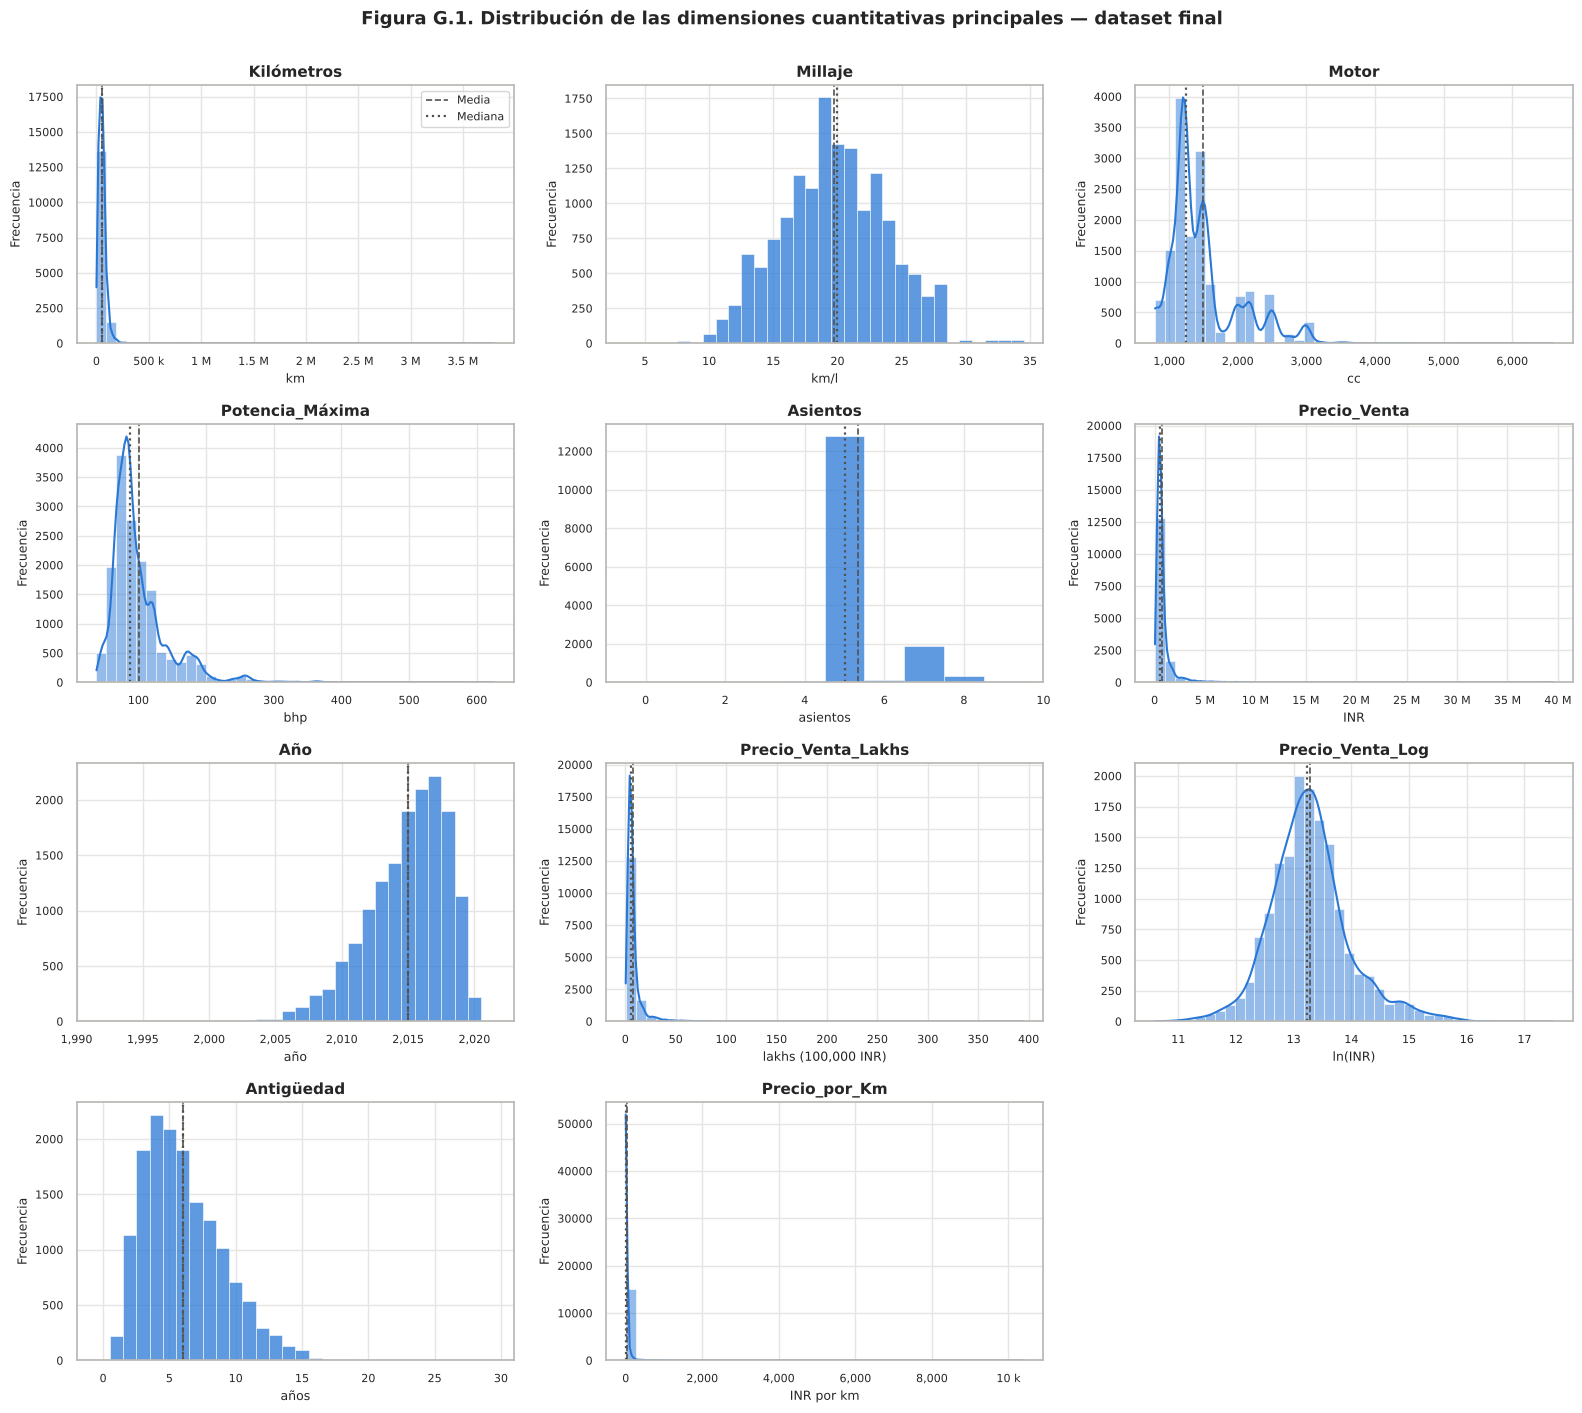

In [11]:
# =====================================================================
# Propósito: distribución de las cuantitativas de CarDekho, del precio
#            transformado y de las dimensiones nuevas.
# Entrada:   df[CUANT_PRINCIPALES].
# Salida:    Figura G.1 (figuras/figura_G1_distribucion_cuantitativas_final.png).
# =====================================================================
UNIDADES = {"Kilómetros": "km", "Millaje": "km/l", "Motor": "cc", "Potencia_Máxima": "bhp",
            "Asientos": "asientos", "Precio_Venta": "INR", "Año": "año",
            "Precio_Venta_Lakhs": "lakhs (100,000 INR)", "Precio_Venta_Log": "ln(INR)",
            "Antigüedad": "años", "Precio_por_Km": "INR por km",
            "Millaje_Carretera": "km/l", "Millaje_Ciudad": "km/l", "RPM_Maximas": "rpm",
            "Caballos_Fuerza": "hp", "Relacion_Compresion": "adimensional", "Carrera_Piston": "mm",
            "Diametro_Cilindro": "mm", "Tamano_Motor": "cc", "Num_Cilindros": "cilindros",
            "Peso_Vacio": "kg", "Altura": "mm", "Ancho": "mm", "Longitud": "mm",
            "Distancia_Ejes": "mm", "Num_Puertas": "puertas"}
graficar_distribuciones_cuantitativas(
    df, CUANT_PRINCIPALES, UNIDADES,
    "Figura G.1. Distribución de las dimensiones cuantitativas principales — dataset final",
    "figura_G1_distribucion_cuantitativas_final.png")
plt.show()

**¿Qué hace esta celda?** Dibuja la Figura G.2 con las mismas gráficas para las 15 cuantitativas de UCI.

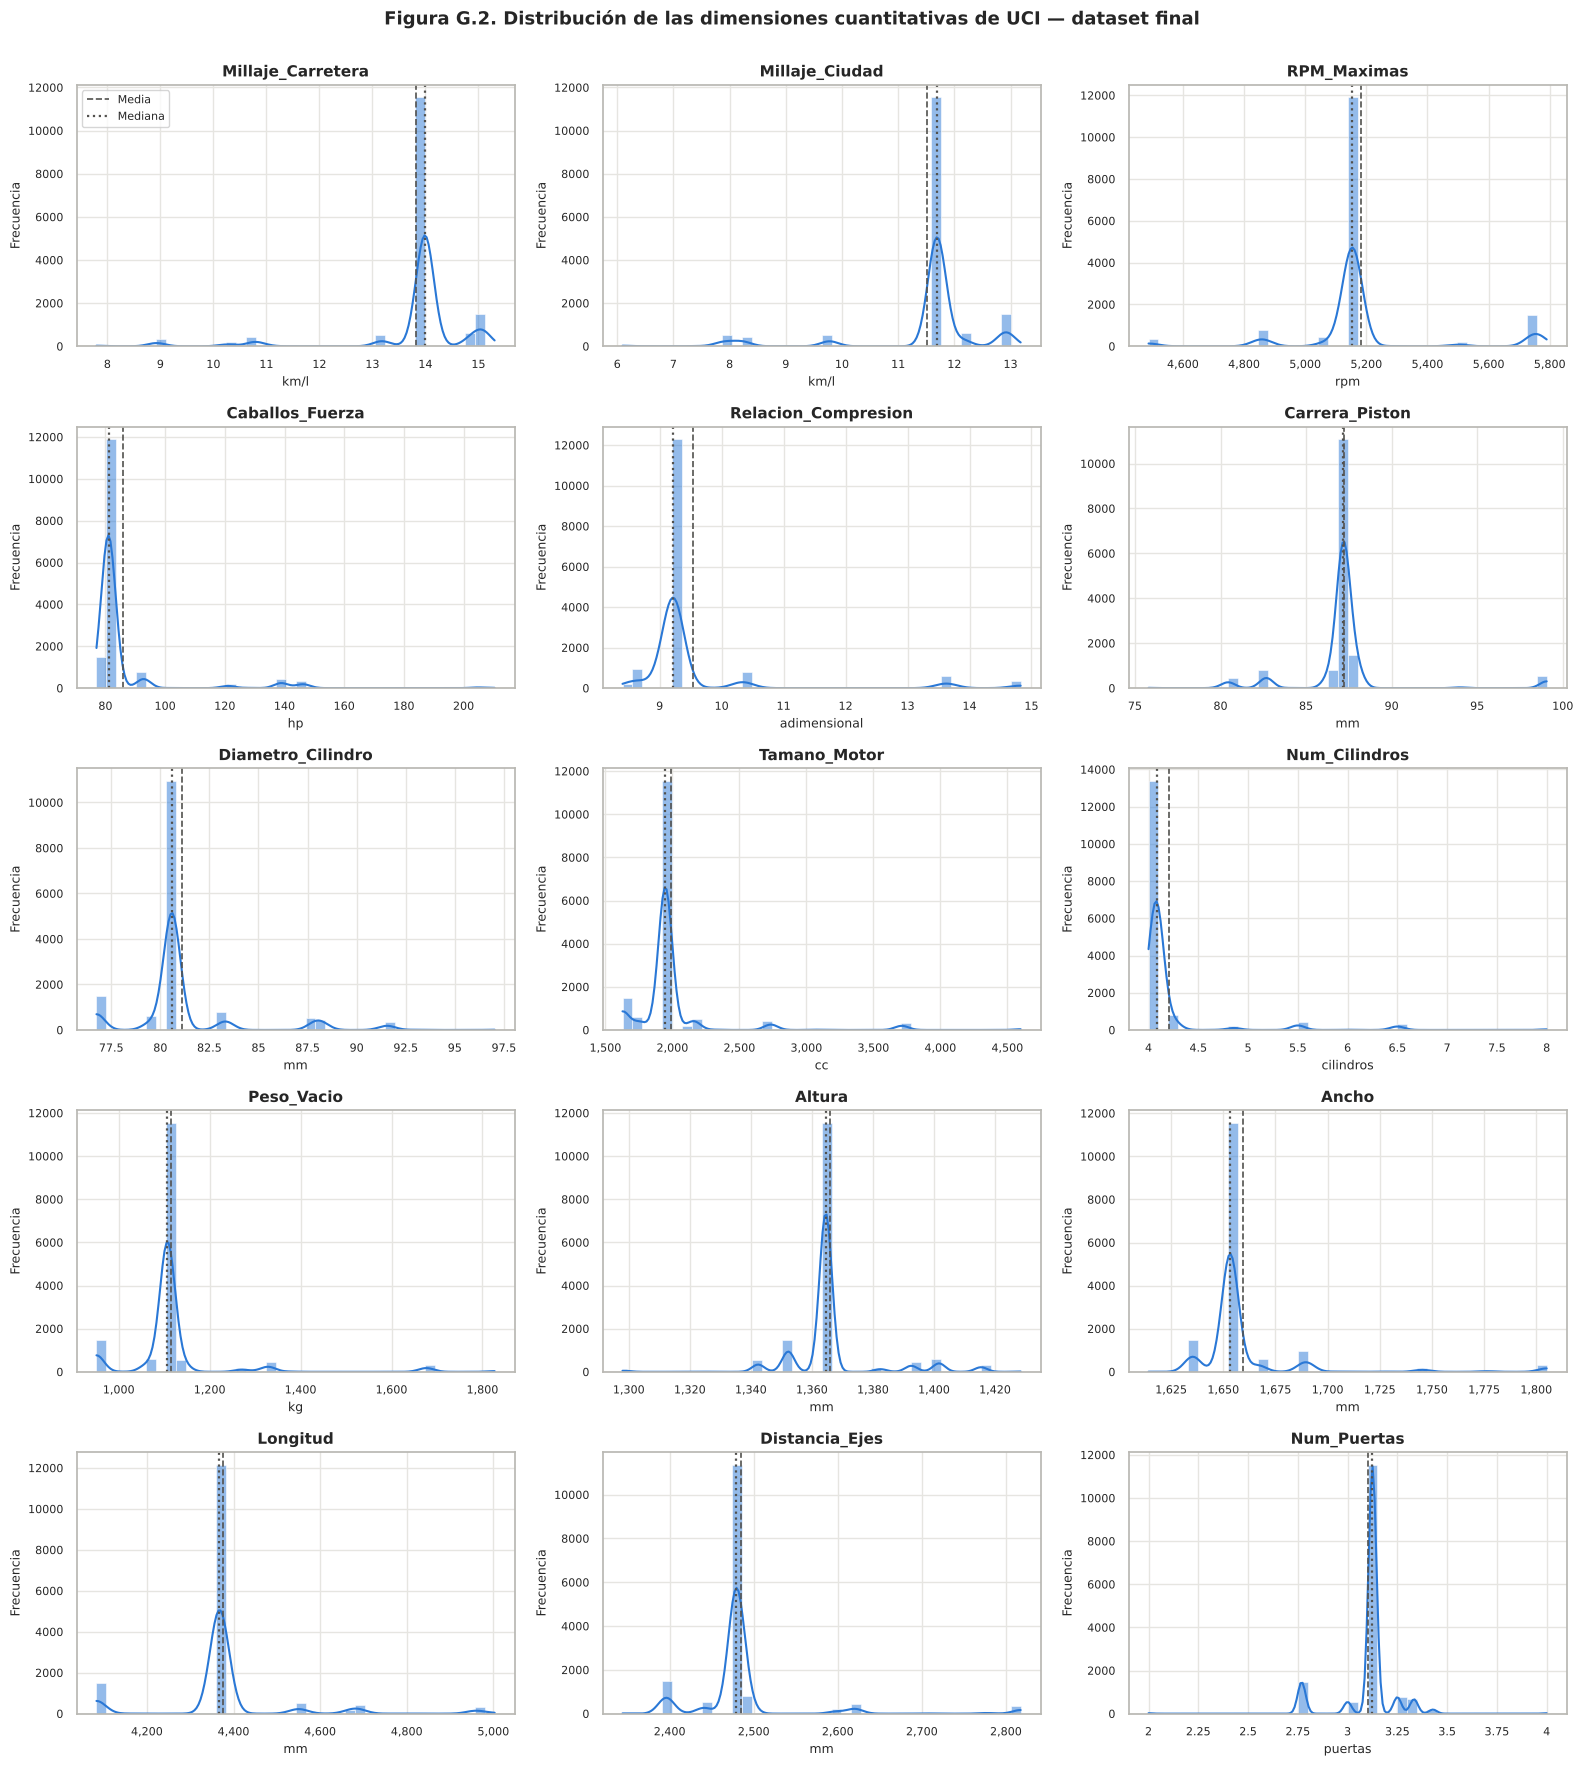

In [12]:
# =====================================================================
# Propósito: distribución de las cuantitativas provenientes de UCI.
# Entrada:   df[CUANT_UCI].
# Salida:    Figura G.2 (figuras/figura_G2_distribucion_cuantitativas_uci_final.png).
# =====================================================================
graficar_distribuciones_cuantitativas(
    df, CUANT_UCI, UNIDADES,
    "Figura G.2. Distribución de las dimensiones cuantitativas de UCI — dataset final",
    "figura_G2_distribucion_cuantitativas_uci_final.png")
plt.show()

**¿Qué hace esta celda?** Dibuja la Figura G.3, un pairplot entre las cuantitativas principales.
**¿Por qué no están todas?** Se omiten `Año`, porque es exactamente 2021 − `Antigüedad`, y `Precio_Venta_Lakhs`, porque es `Precio_Venta` entre 100,000: sus diagramas repetirían otros paneles.

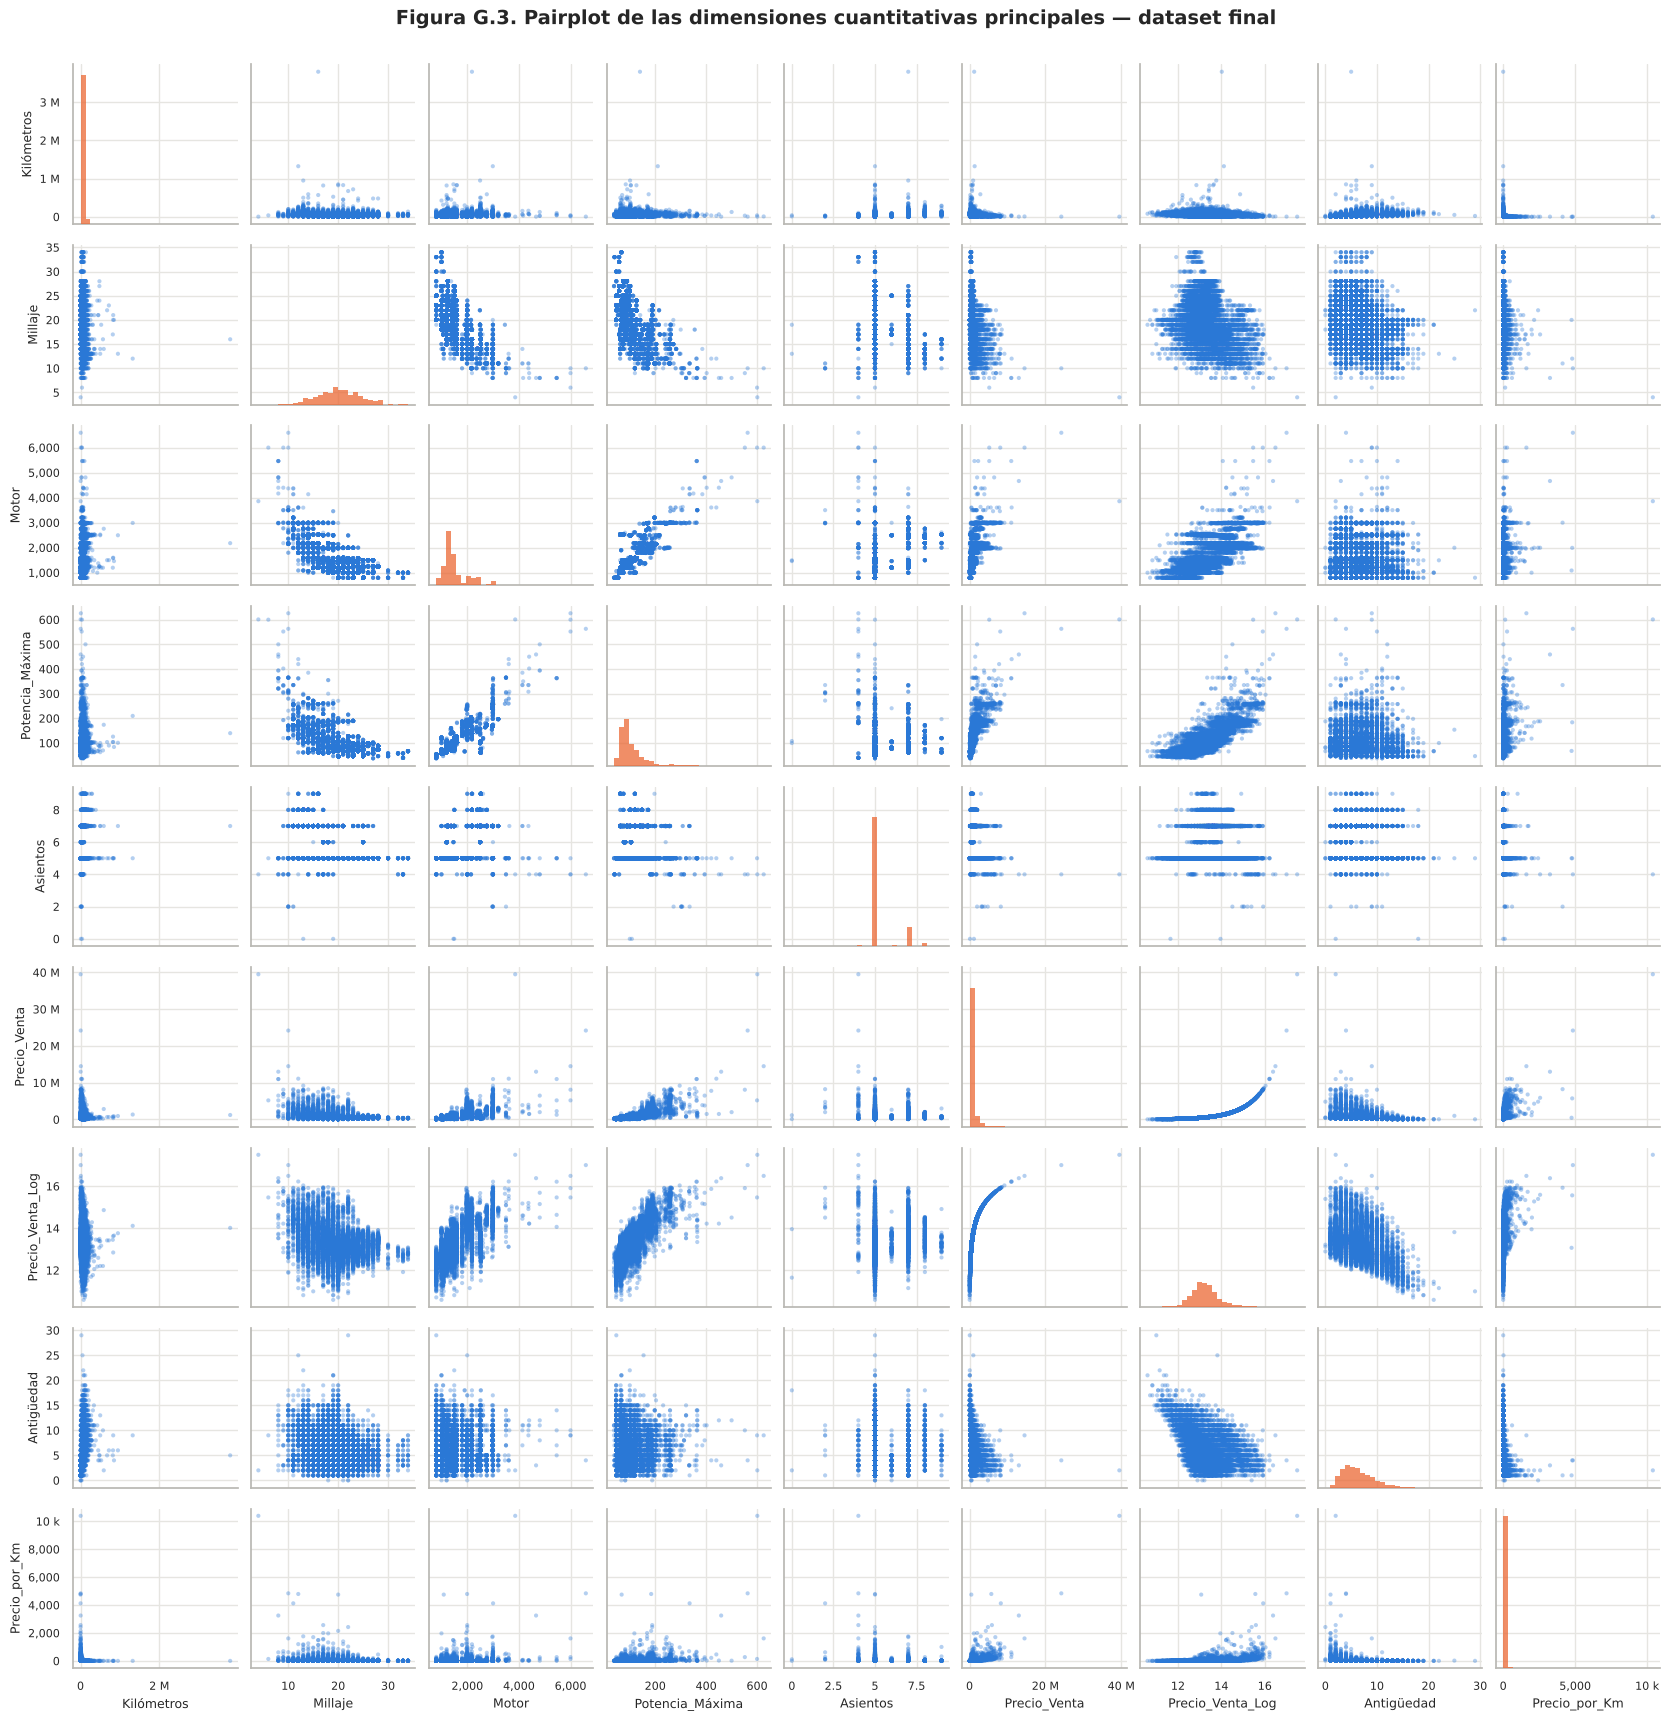

In [13]:
# =====================================================================
# Propósito: pairplot entre las cuantitativas principales.
# Entrada:   df.
# Salida:    Figura G.3 (figuras/figura_G3_pairplot_final.png).
# =====================================================================
PAIRPLOT_PRINCIPAL = ["Kilómetros", "Millaje", "Motor", "Potencia_Máxima", "Asientos",
                      "Precio_Venta", "Precio_Venta_Log", "Antigüedad", "Precio_por_Km"]
graficar_pairplot(df, PAIRPLOT_PRINCIPAL,
                  "Figura G.3. Pairplot de las dimensiones cuantitativas principales — dataset final",
                  "figura_G3_pairplot_final.png", altura=1.9)
plt.show()

**¿Qué hace esta celda?** Dibuja la Figura G.4, un pairplot entre dimensiones de UCI y el precio.
**¿Por qué solo con los registros con datos de UCI?** Los registros imputados tienen todos el mismo valor (la mediana) y formarían un único punto repetido que oculta la relación.

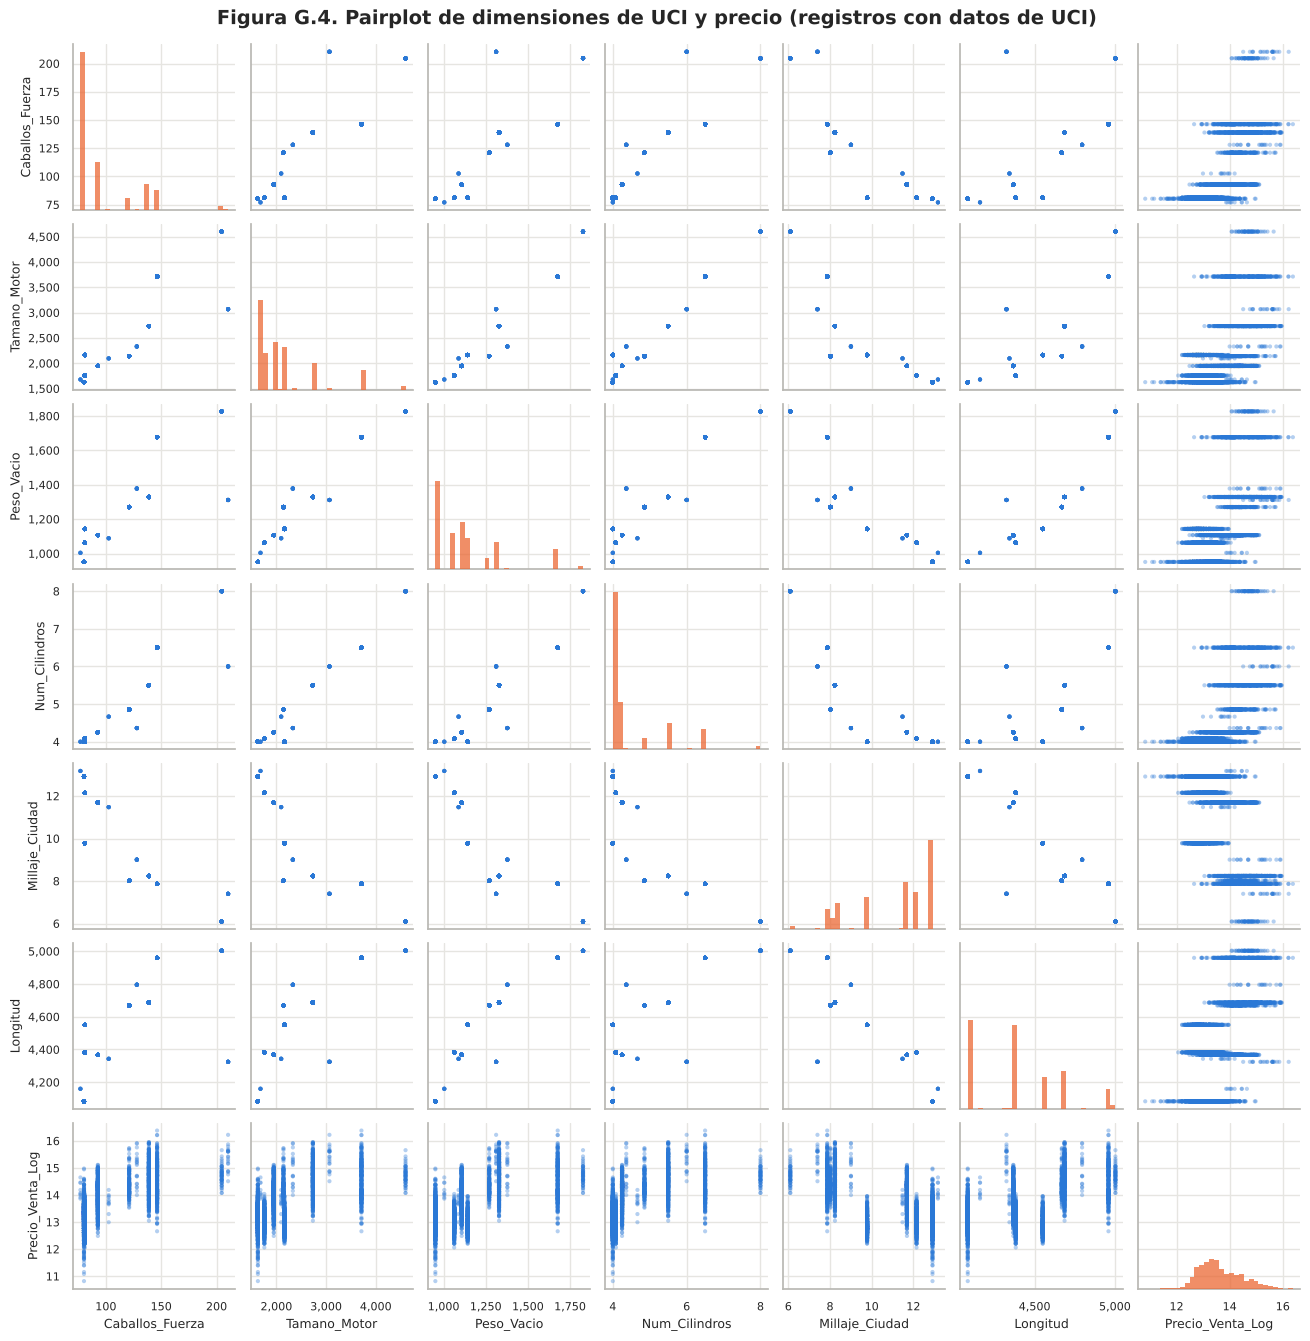

In [14]:
# =====================================================================
# Propósito: pairplot entre dimensiones de UCI y el precio, con los
#            registros que tienen datos reales de UCI.
# Entrada:   con_uci (Tiene_Datos_UCI = 1).
# Salida:    Figura G.4 (figuras/figura_G4_pairplot_uci_final.png).
# =====================================================================
PAIRPLOT_UCI = ["Caballos_Fuerza", "Tamano_Motor", "Peso_Vacio", "Num_Cilindros",
                "Millaje_Ciudad", "Longitud", "Precio_Venta_Log"]
graficar_pairplot(con_uci, PAIRPLOT_UCI,
                  "Figura G.4. Pairplot de dimensiones de UCI y precio (registros con datos de UCI)",
                  "figura_G4_pairplot_uci_final.png", altura=1.9)
plt.show()

**¿Qué hace esta celda?** Dibuja la Figura G.5, el mapa de calor con la correlación de Pearson entre las 26 dimensiones cuantitativas (sin las codificadas), con todos los registros. Después muestra la correlación de cada una con `Precio_Venta` y con `Precio_Venta_Log`, de mayor a menor.

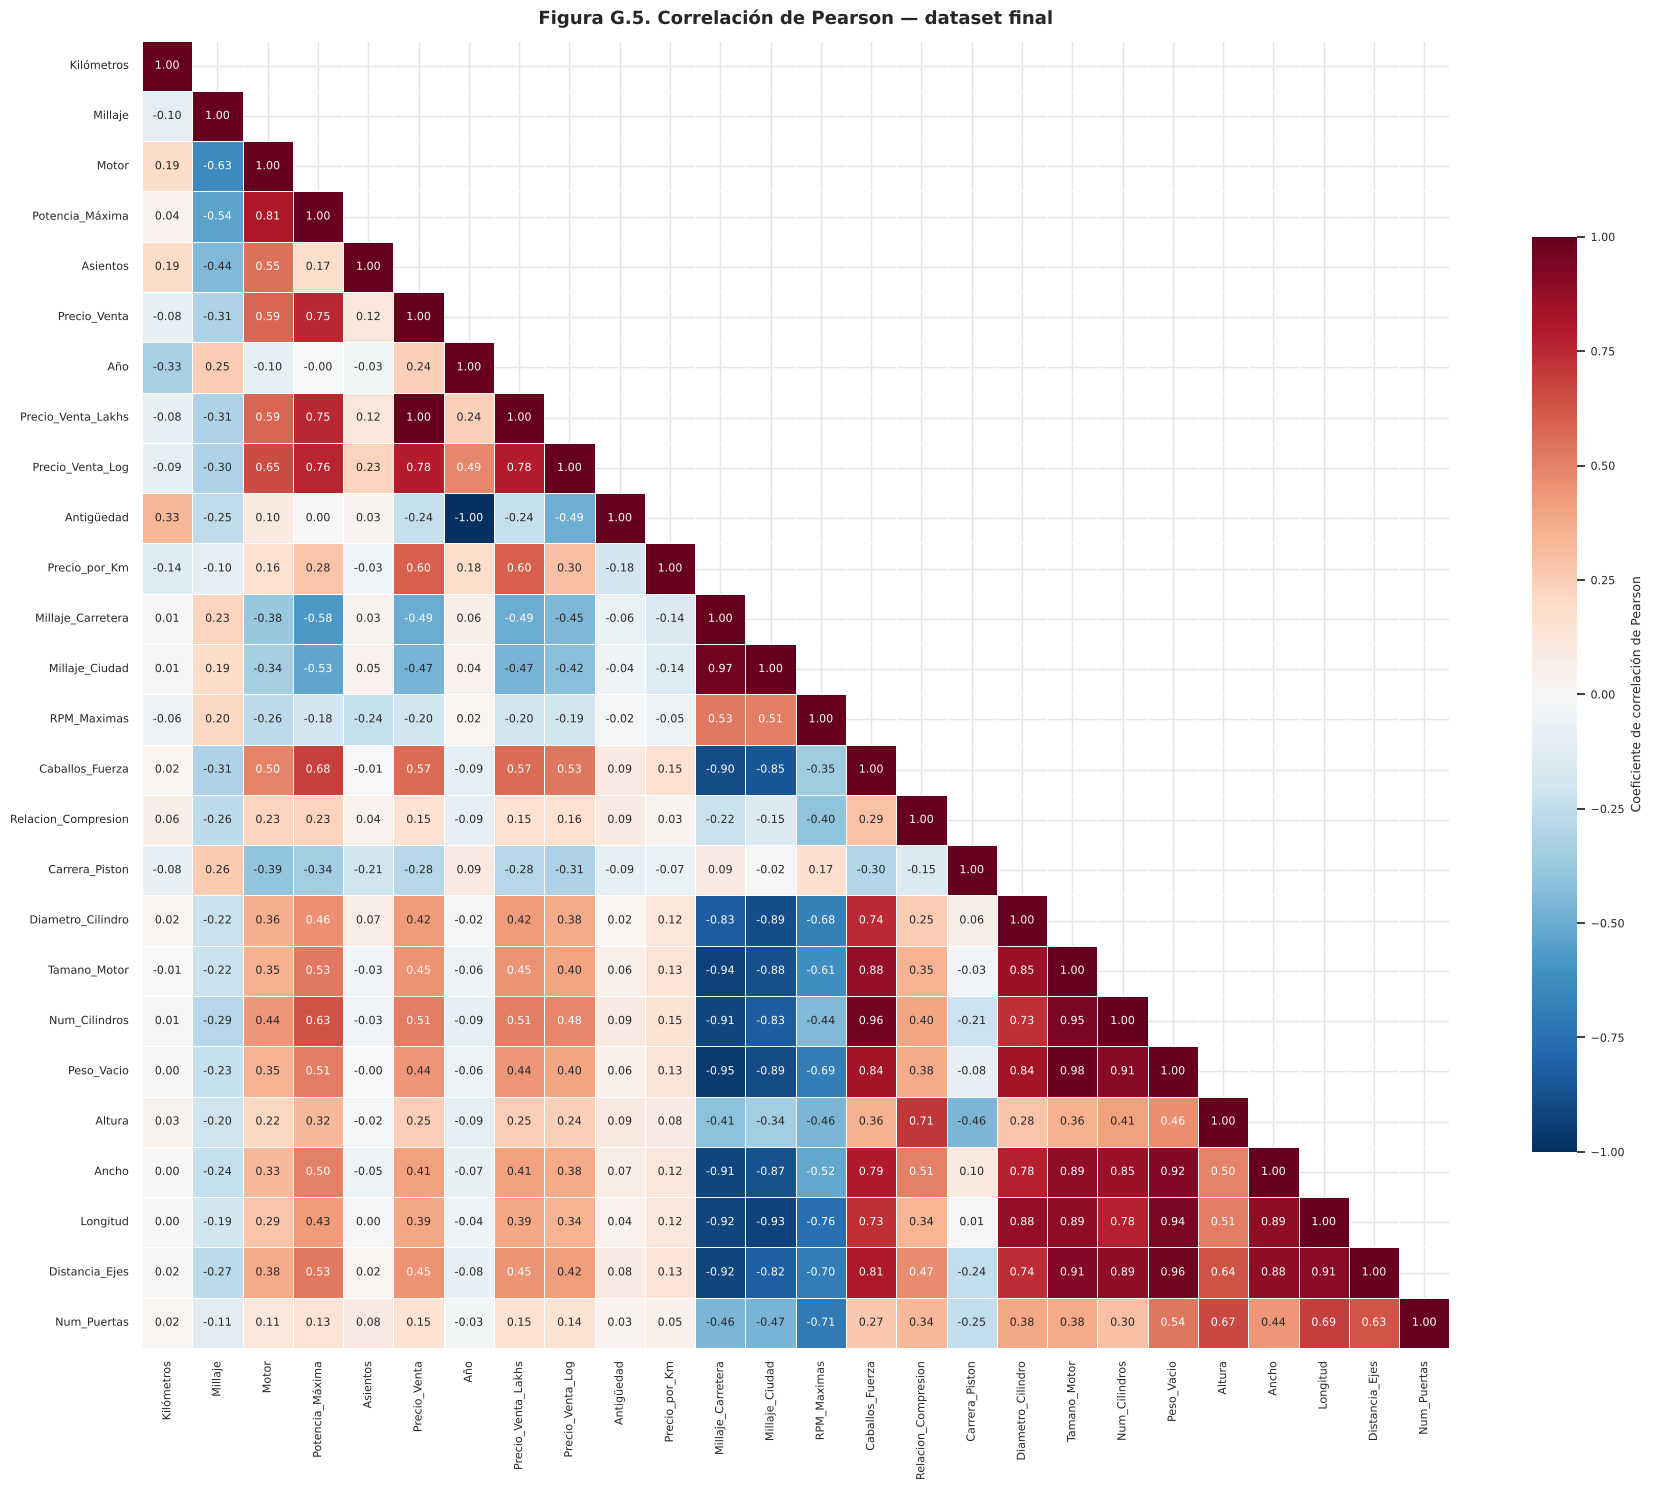

,Precio_Venta,Precio_Venta_Log
Potencia_Máxima,0.751,0.759
Motor,0.586,0.654
Caballos_Fuerza,0.566,0.534
Año,0.241,0.486
Num_Cilindros,0.514,0.485
Distancia_Ejes,0.446,0.418
Tamano_Motor,0.452,0.405
Peso_Vacio,0.441,0.398
Ancho,0.411,0.378
Diametro_Cilindro,0.425,0.375


In [15]:
# =====================================================================
# Propósito: mapa de calor de correlaciones y correlación de cada
#            dimensión con Precio_Venta y con Precio_Venta_Log.
# Entrada:   df[CUANT_PRINCIPALES + CUANT_UCI].
# Salida:    Figura G.5 (figuras/figura_G5_correlacion_final.png) y tabla.
# =====================================================================
CUANT_TODAS = CUANT_PRINCIPALES + CUANT_UCI
corr_final = graficar_mapa_calor(df, CUANT_TODAS,
                                 "Figura G.5. Correlación de Pearson — dataset final",
                                 "figura_G5_correlacion_final.png")
plt.show()
corr_precio = corr_final[["Precio_Venta", "Precio_Venta_Log"]].drop(
    ["Precio_Venta", "Precio_Venta_Log", "Precio_Venta_Lakhs"])
corr_precio.sort_values("Precio_Venta_Log", ascending=False)

**¿Qué hace esta celda?** Dibuja la Figura G.6 con la frecuencia de cada clase de las cualitativas. `Nombre` y `Modelo` muestran solo las 30 clases más frecuentes; sus tablas completas están en G.32. `Marca_Homologada` se omite porque tiene las mismas 30 clases que `Marca`, escritas en minúsculas.

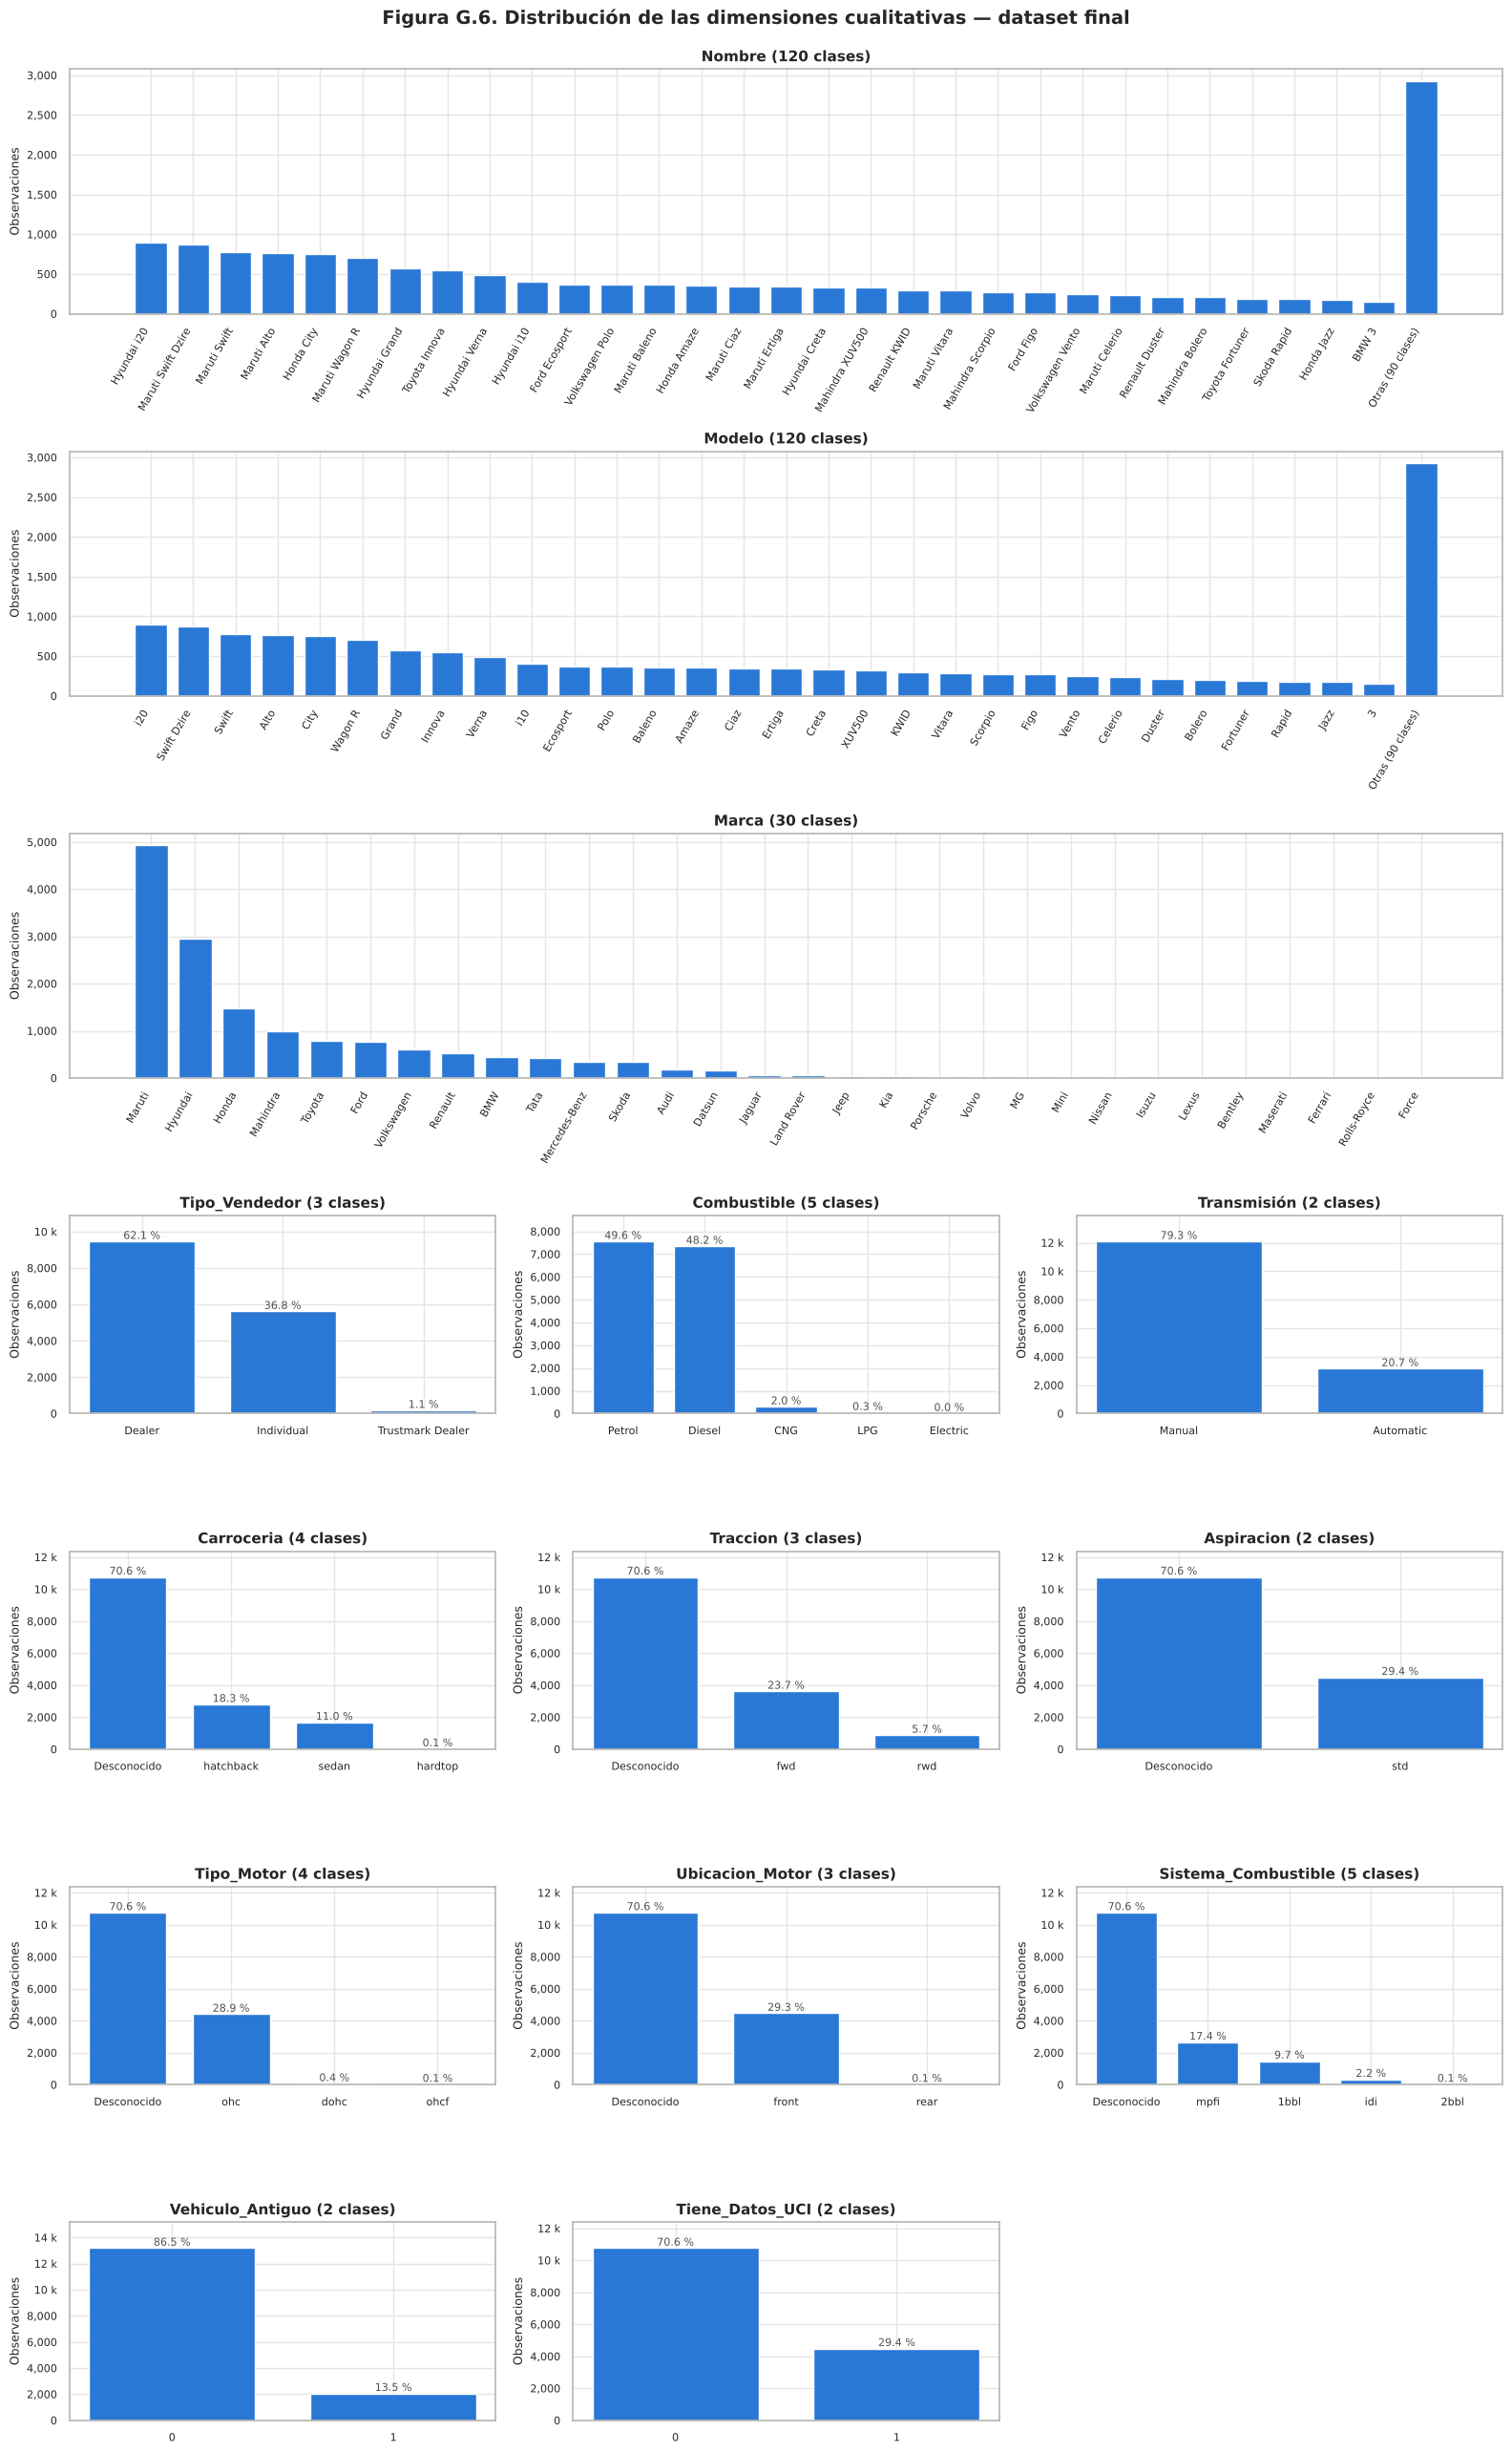

In [16]:
# =====================================================================
# Propósito: distribución de cada dimensión cualitativa.
# Entrada:   df[CUALITATIVAS].
# Salida:    Figura G.6 (figuras/figura_G6_distribucion_cualitativas_final.png).
# =====================================================================
graficar_distribuciones_cualitativas(
    df, CUALI_GRAFICAS,
    "Figura G.6. Distribución de las dimensiones cualitativas — dataset final",
    "figura_G6_distribucion_cualitativas_final.png")
plt.show()

**¿Qué hace esta celda?** Compara cada dimensión categórica contra `Precio_Venta`: agrupa las observaciones por categoría (eje X) y las ordena de mayor a menor precio promedio (eje Y) en la Figura G.7. Las tablas incluyen el número de observaciones y el precio mediano. En `Nombre` y `Modelo` la gráfica muestra las 30 categorías más caras; las tablas están completas.


Nombre vs Precio_Venta (INR)


,Observaciones,Precio promedio,Precio mediano
Nombre,,,
Ferrari GTC4Lusso,1,"39,500,000.000","39,500,000.000"
Rolls-Royce Ghost,1,"24,200,000.000","24,200,000.000"
Bentley Continental,3,"9,266,666.667","8,100,000.000"
Lexus RX,2,"7,100,000.000","7,100,000.000"
Mercedes-Benz GLS,12,"6,781,083.333","6,950,000.000"
Maserati Ghibli,1,"6,200,000.000","6,200,000.000"
Maserati Quattroporte,1,"6,000,000.000","6,000,000.000"
Porsche Macan,2,"5,985,000.000","5,985,000.000"
BMW X4,6,"5,570,000.000","5,600,000.000"



Modelo vs Precio_Venta (INR)


,Observaciones,Precio promedio,Precio mediano
Modelo,,,
GTC4Lusso,1,"39,500,000.000","39,500,000.000"
Ghost,1,"24,200,000.000","24,200,000.000"
Continental,3,"9,266,666.667","8,100,000.000"
RX,2,"7,100,000.000","7,100,000.000"
GLS,12,"6,781,083.333","6,950,000.000"
Ghibli,1,"6,200,000.000","6,200,000.000"
Quattroporte,1,"6,000,000.000","6,000,000.000"
Macan,2,"5,985,000.000","5,985,000.000"
X4,6,"5,570,000.000","5,600,000.000"



Marca vs Precio_Venta (INR)


...

,Observaciones,Precio promedio,Precio mediano
Sistema_Combustible,,,
idi,333,"2,488,099.099","1,800,000.000"
mpfi,2655,"1,323,617.326","850,000.000"
2bbl,20,"1,197,200.000","1,127,000.000"
1bbl,1476,"617,452.575","590,000.000"
Desconocido,10760,"607,017.089","520,000.000"



Vehiculo_Antiguo vs Precio_Venta (INR)


,Observaciones,Precio promedio,Precio mediano
Vehiculo_Antiguo,,,
0,13187,"834,916.433","600,000.000"
1,2057,"388,675.681","275,000.000"



Tiene_Datos_UCI vs Precio_Venta (INR)


,Observaciones,Precio promedio,Precio mediano
Tiene_Datos_UCI,,,
1,4484,"1,177,084.077","725,000.000"
0,10760,"607,017.089","520,000.000"


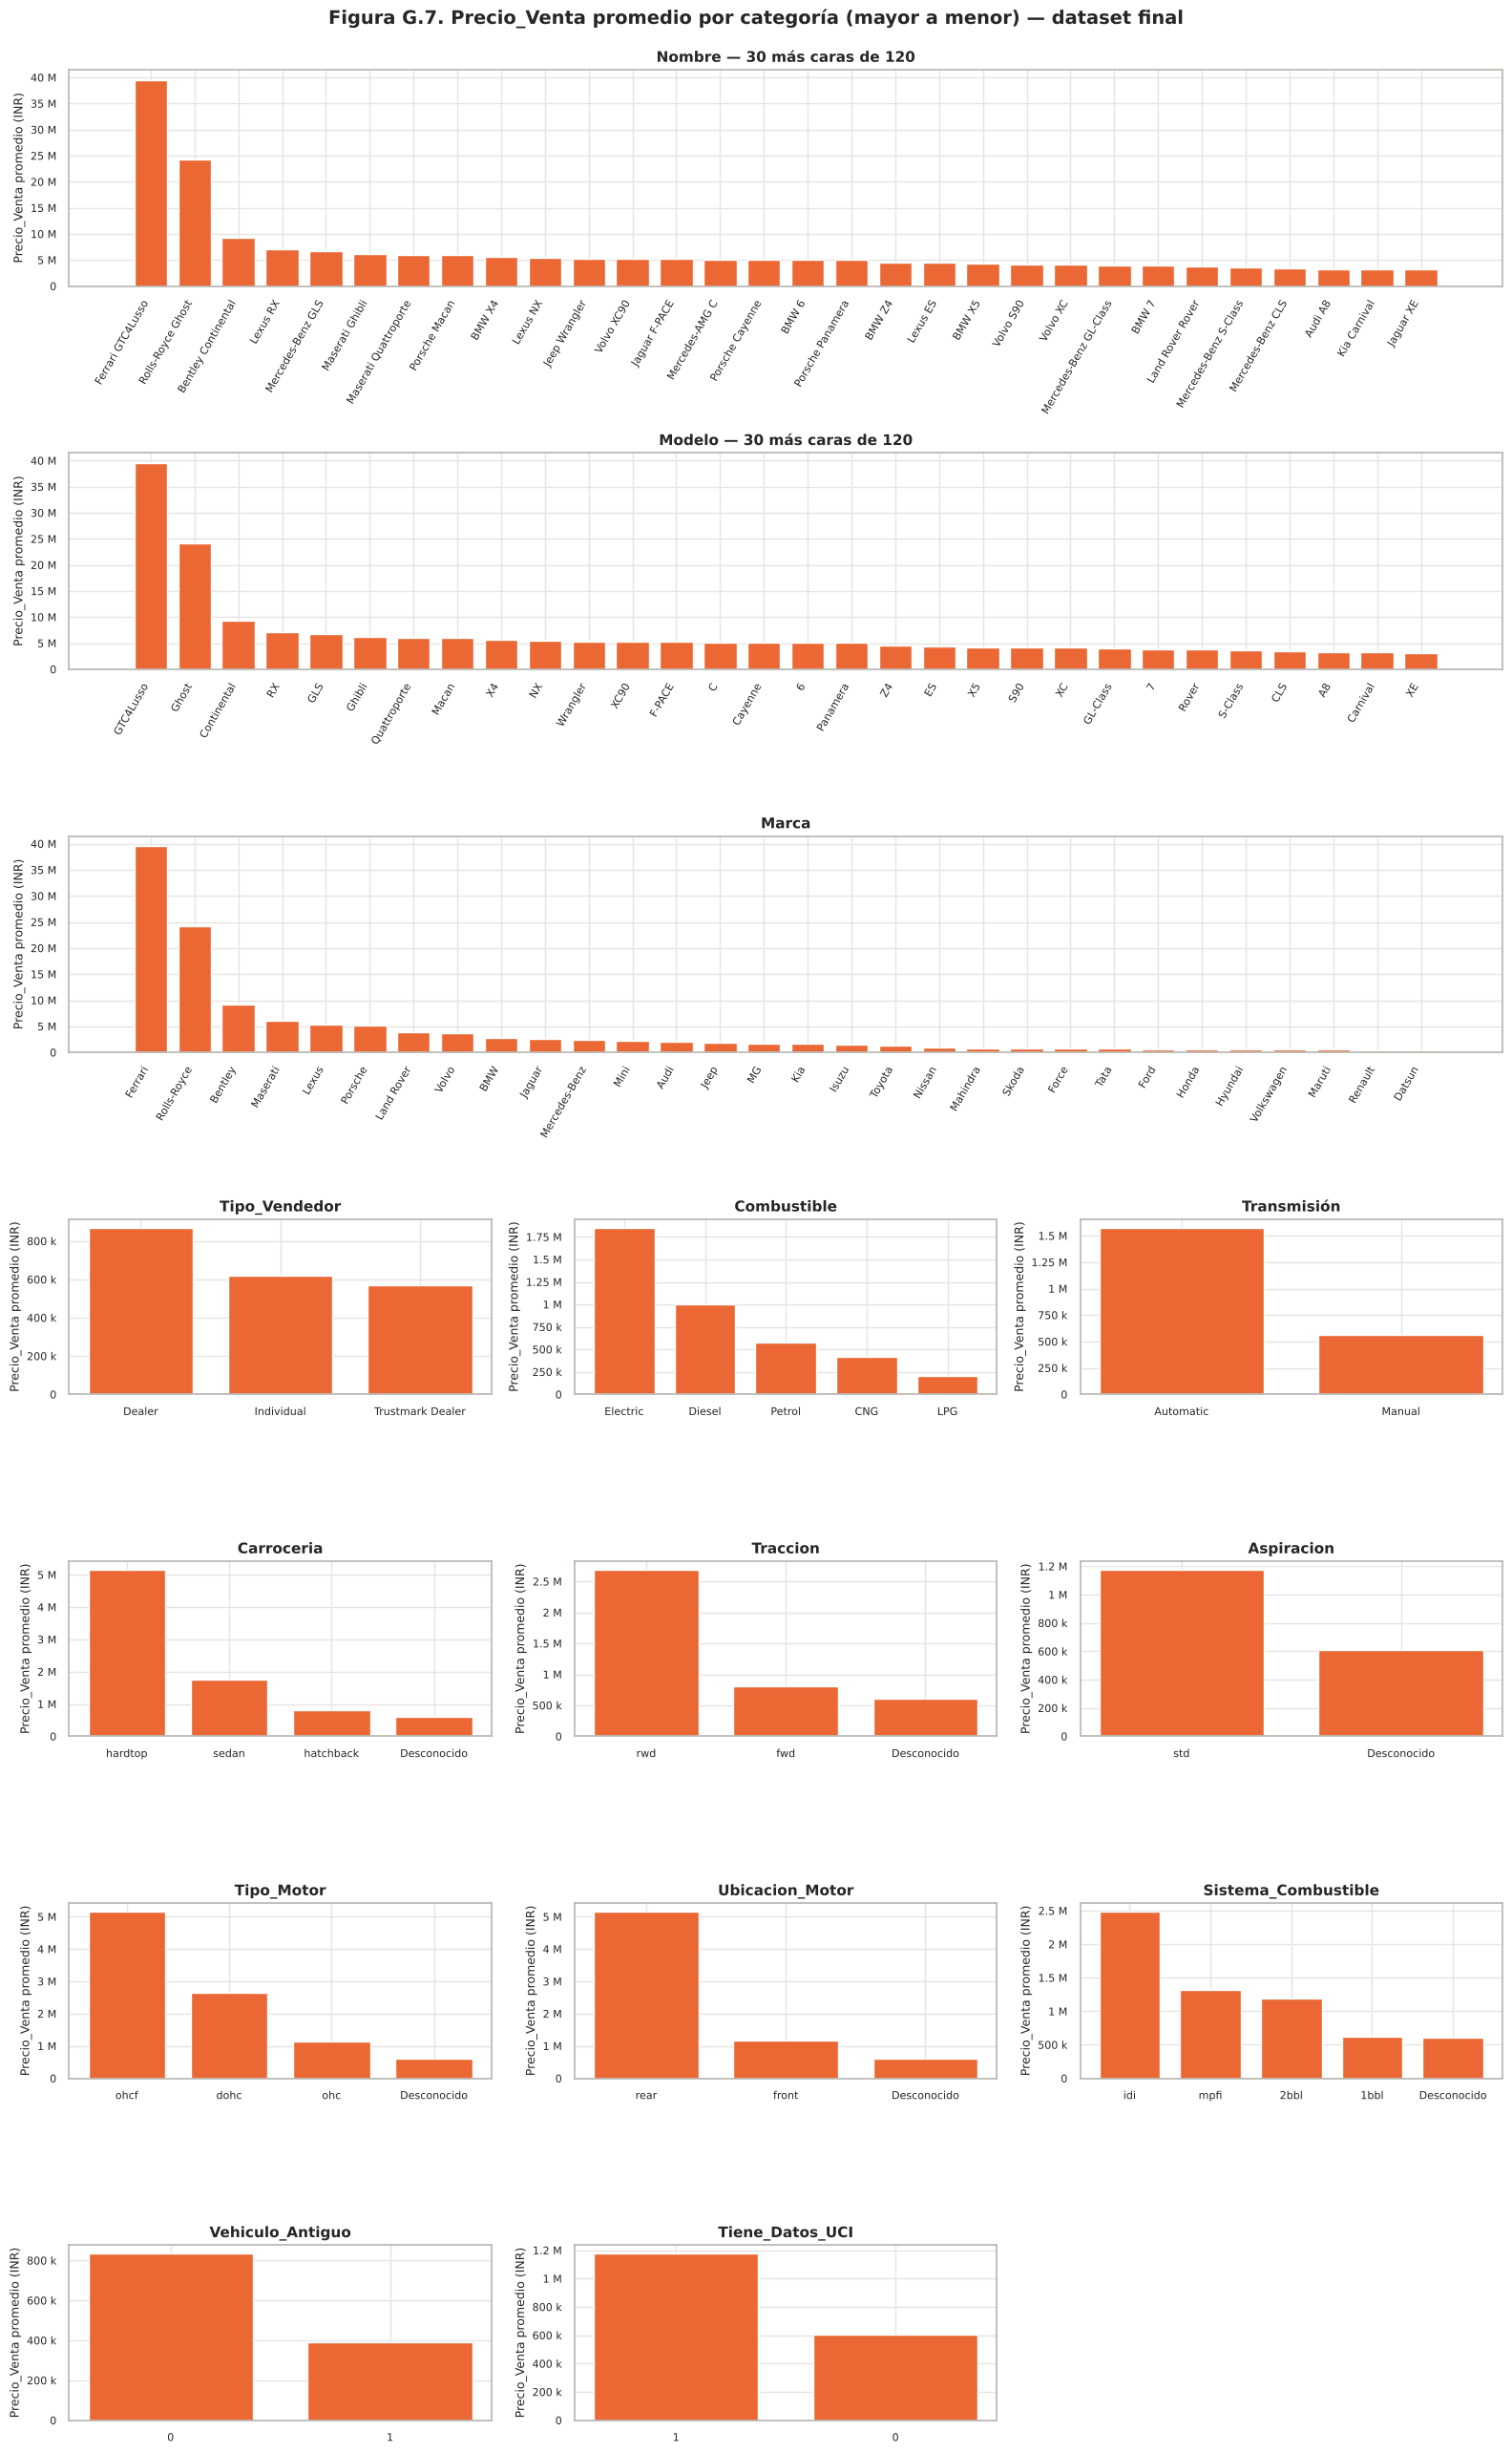

In [17]:
# =====================================================================
# Propósito: comparar cada dimensión categórica contra Precio_Venta,
#            agrupando y ordenando de mayor a menor.
# Entrada:   df[CUALITATIVAS + ["Precio_Venta"]].
# Salida:    tablas por dimensión y Figura G.7
#            (figuras/figura_G7_categoricas_vs_precio_final.png).
# =====================================================================
for col in CUALI_GRAFICAS:
    print(f"\n{col} vs Precio_Venta (INR)")
    display(precio_por_categoria(df, col, "Precio_Venta"))
graficar_categorias_vs_precio(
    df, CUALI_GRAFICAS, "Precio_Venta", "INR",
    "Figura G.7. Precio_Venta promedio por categoría (mayor a menor) — dataset final",
    "figura_G7_categoricas_vs_precio_final.png")
plt.show()

### Análisis de las dimensiones nuevas
El inciso 33 pide analizar en particular `Antigüedad`, `Marca`, `Modelo`, `Precio_por_Km` y `Vehiculo_Antiguo`.

**¿Qué hace esta celda?** Dibuja la Figura G.8, que reúne las tres dimensiones creadas en la Sección F. Para `Vehiculo_Antiguo` usa el mismo umbral de 10 años de la Sección F (observación 13).

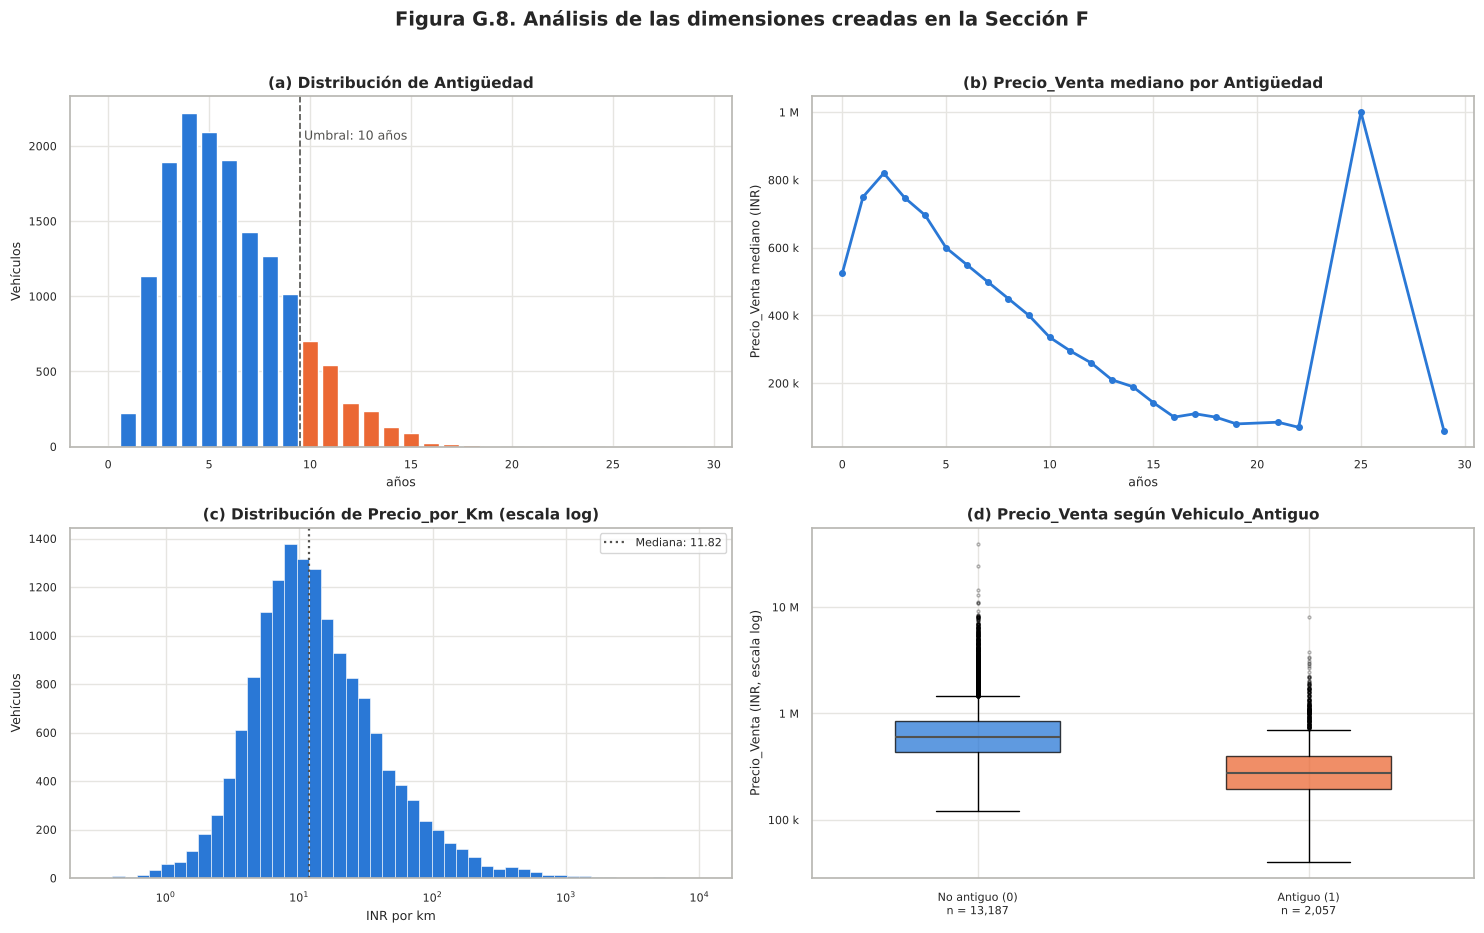

In [18]:
# =====================================================================
# Propósito: análisis gráfico de Antigüedad, Precio_por_Km y
#            Vehiculo_Antiguo.
# Entrada:   df.
# Salida:    Figura G.8 (figuras/figura_G8_nuevas_caracteristicas.png).
# =====================================================================
UMBRAL_ANTIGUO = 10  # Mismo umbral de la Sección F (observación 13)
graficar_nuevas_caracteristicas(df, "Figura G.8. Análisis de las dimensiones creadas en la Sección F",
                                "figura_G8_nuevas_caracteristicas.png", umbral=UMBRAL_ANTIGUO)
plt.show()

**¿Qué hace esta celda?** Da la evidencia numérica de la Figura G.8: el precio por cada año de antigüedad; el precio, `Precio_por_Km` y los kilómetros medianos de cada grupo de `Vehiculo_Antiguo`; y la correlación de las tres dimensiones con el precio.

In [19]:
# =====================================================================
# Propósito: evidencia numérica de las dimensiones nuevas: precio por
#            antigüedad y por Vehiculo_Antiguo, correlaciones y
#            Precio_por_Km por grupo.
# Entrada:   df.
# Salida:    tablas de resumen.
# =====================================================================
print("Precio_Venta por Antigüedad (ordenado por años):")
display(precio_por_categoria(df, "Antigüedad", "Precio_Venta").sort_index())

print("Precio_Venta y Precio_por_Km por Vehiculo_Antiguo:")
display(df.groupby("Vehiculo_Antiguo").agg(
    Observaciones=("Precio_Venta", "size"),
    Precio_mediano=("Precio_Venta", "median"),
    Precio_por_Km_mediano=("Precio_por_Km", "median"),
    Kilometros_mediano=("Kilómetros", "median")))

print("Correlación de las dimensiones nuevas con el precio:")
display(df[["Antigüedad", "Precio_por_Km", "Vehiculo_Antiguo", "Precio_Venta", "Precio_Venta_Log"]]
        .corr().loc[["Antigüedad", "Precio_por_Km", "Vehiculo_Antiguo"], ["Precio_Venta", "Precio_Venta_Log"]])

Precio_Venta por Antigüedad (ordenado por años):


,Observaciones,Precio promedio,Precio mediano
Antigüedad,,,
0,4,"1,575,000.000","525,000.000"
1,221,"1,096,977.376","750,000.000"
2,1135,"1,144,513.656","820,000.000"
3,1896,"977,327.004","748,000.000"
4,2220,"949,041.892","695,500.000"
5,2094,"820,205.826","600,000.000"
6,1904,"728,160.714","550,000.000"
7,1427,"700,072.179","500,000.000"
8,1271,"627,511.408","450,000.000"


Precio_Venta y Precio_por_Km por Vehiculo_Antiguo:


,Observaciones,Precio_mediano,Precio_por_Km_mediano,Kilometros_mediano
Vehiculo_Antiguo,,,,
0,13187,"600,000.000",13.600,"47,000.000"
1,2057,"275,000.000",3.968,"70,000.000"


Correlación de las dimensiones nuevas con el precio:


,Precio_Venta,Precio_Venta_Log
Antigüedad,-0.241,-0.486
Precio_por_Km,0.597,0.299
Vehiculo_Antiguo,-0.170,-0.395


**¿Qué hace esta celda?** Analiza `Marca` y `Modelo`: número de clases, porcentaje de los registros que concentran las 10 más frecuentes, cuántas clases tienen menos de 10 registros y el precio de las 10 más frecuentes. Se complementa con las Figuras G.6 y G.7.

In [20]:
# =====================================================================
# Propósito: análisis de Marca y Modelo: clases, concentración y
#            precio de las 10 más frecuentes.
# Entrada:   df["Marca"], df["Modelo"], df["Precio_Venta"].
# Salida:    tablas de resumen.
# =====================================================================
for col in ["Marca", "Modelo"]:
    tabla = precio_por_categoria(df, col, "Precio_Venta").sort_values("Observaciones", ascending=False)
    tabla["% del total"] = tabla["Observaciones"] / len(df) * 100
    top10 = tabla.head(10)
    print(f"\n{col}: {df[col].nunique()} clases; las 10 más frecuentes concentran "
          f"{top10['% del total'].sum():.1f} % de los registros; "
          f"{(tabla['Observaciones'] < 10).sum()} clases tienen menos de 10 registros.")
    display(top10)


Marca: 30 clases; las 10 más frecuentes concentran 91.3 % de los registros; 7 clases tienen menos de 10 registros.


,Observaciones,Precio promedio,Precio mediano,% del total
Marca,,,,
Maruti,4933,"486,985.379","465,000.000",32.360
Hyundai,2952,"576,478.997","525,000.000",19.365
Honda,1476,"617,452.575","590,000.000",9.682
Mahindra,999,"788,613.614","750,000.000",6.553
Toyota,789,"1,371,496.831","1,275,000.000",5.176
Ford,776,"633,716.495","566,000.000",5.091
Volkswagen,614,"515,519.544","499,000.000",4.028
Renault,527,"442,529.412","395,000.000",3.457
BMW,436,"2,686,674.312","2,287,500.000",2.860



Modelo: 120 clases; las 10 más frecuentes concentran 44.5 % de los registros; 36 clases tienen menos de 10 registros.


,Observaciones,Precio promedio,Precio mediano,% del total
Modelo,,,,
i20,898,"543,195.991","550,000.000",5.891
Swift Dzire,875,"525,498.286","521,000.000",5.740
Swift,774,"472,288.114","466,500.000",5.077
Alto,768,"245,139.323","250,000.000",5.038
City,750,"624,753.333","620,000.000",4.920
Wagon R,709,"307,085.860","319,000.000",4.651
Grand,569,"474,854.130","475,000.000",3.733
Innova,544,"1,176,159.926","1,099,500.000",3.569
Verna,488,"652,069.672","592,500.000",3.201


### Conclusiones G.33
- **Distribuciones cuantitativas (Figuras G.1 y G.2):**
  - `Precio_Venta` y `Precio_Venta_Lakhs` tienen la misma forma, muy sesgada a la derecha, porque dividir entre 100,000 solo cambia la escala. `Precio_Venta_Log` tiene forma de campana (asimetría de 0.56).
  - `Millaje`, `Motor` y `Potencia_Máxima` conservan la forma que tenían en la Sección A; el redondeo no la cambió. `Antigüedad` es el reflejo de `Año`, y `Precio_por_Km` se concentra cerca de cero con una cola muy larga.
  - Las dimensiones de UCI no forman distribuciones continuas: tienen una barra dominante en el valor imputado (70.6 % de los registros) y unas pocas barras, una por fabricante.
- **Pairplot (Figuras G.3 y G.4):**
  - Se mantienen las relaciones de la Sección A: `Motor` y `Potencia_Máxima` crecen juntas, el precio sube con la potencia y baja con la antigüedad. Con `Precio_Venta_Log` estas relaciones se ven más lineales que con el precio original.
  - `Precio_por_Km` tiende a disminuir cuando aumentan los kilómetros, como se espera por su fórmula.
  - En la Figura G.4 los puntos forman columnas, una por fabricante: la relación entre el precio y las dimensiones de UCI es entre fabricantes, no entre vehículos.
- **Correlaciones (Figura G.5):**
  - El precio se relaciona sobre todo con `Potencia_Máxima` (0.75 con `Precio_Venta` y 0.76 con `Precio_Venta_Log`) y con `Motor` (0.59 y 0.65). Con el logaritmo, la correlación con `Antigüedad` pasa de −0.24 a −0.49.
  - `Año` y `Antigüedad` tienen correlación de −1, y `Precio_Venta_Lakhs` de 1 con `Precio_Venta`, porque cada una se calcula a partir de la otra. Las dimensiones de UCI están muy correlacionadas entre sí porque todas son promedios del mismo fabricante.
- **Cualitativas y precio por categoría (Figuras G.6 y G.7):**
  - Se mantienen el desbalance de clases y el orden de precios de la Sección A: lujo arriba, automáticos unas 2.8 veces más caros que los manuales en promedio (1,577,104 contra 565,708 INR) y diésel por encima de gasolina, GNC y GLP.
  - En las categóricas de UCI, Desconocido tiene el precio promedio más bajo (607,017 INR) porque agrupa a las marcas populares sin datos de UCI (Maruti, Hyundai, Mahindra, Tata). Las clases de UCI funcionan como sustitutos de la marca: hardtop son los 21 Porsche y rwd son principalmente BMW y Mercedes-Benz.
- **Dimensiones nuevas (Figura G.8):**
  - `Antigüedad`: el precio mediano baja de 820,000 INR a los 2 años a 142,500 INR a los 15. Los extremos tienen muy pocos registros (4 con 0 años y 1 con 25 años que vale 1,000,000 INR), así que esos puntos no son representativos.
  - `Vehiculo_Antiguo`: los antiguos (13.5 %) tienen un precio mediano de 275,000 INR contra 600,000 de los demás, y más kilómetros (mediana de 70,000 contra 47,000).
  - `Precio_por_Km`: en escala logarítmica tiene forma de campana alrededor de su mediana (11.82 INR/km); la mediana de los antiguos es 3.97 INR/km y la de los demás 13.60. Por su asimetría conviene describirla con la mediana.
  - `Marca`: 30 clases; las 10 más frecuentes reúnen el 91.3 % de los registros y 7 marcas tienen menos de 10.
  - `Modelo`: 120 clases; los 10 más frecuentes reúnen el 44.5 % y 36 modelos tienen menos de 10 registros, así que sus precios promedio deben leerse con cuidado.

# Sección H — Análisis y conclusiones (inciso 34)
**Responsable:** Ricardo

**Propósito:** identificar las diferencias entre el análisis exploratorio inicial (Sección A) y el final (Sección G), argumentar sus causas a partir de lo que hizo cada etapa del proceso y presentar conclusiones sustentadas en los resultados estadísticos y gráficos.

**Insumos:**
- **Inicio:** los datos originales de CarDekho y UCI Automobile, descargados igual que en la Sección A y renombrados al español con los diccionarios de la Sección B.
- **Etapas intermedias:** los CSV que deja cada sección en `data/processed/`.
- **Final:** `data/processed/dataset_final_procesado.csv`, el mismo que analiza la Sección G.

**¿Qué hace esta celda?** Descarga los datos originales (requiere internet), lee el archivo de cada etapa en el orden de ejecución del README y muestra el tamaño de cada uno.

In [21]:
# =====================================================================
# Propósito: cargar los datos originales, los de cada etapa y el final.
# Entrada:   Kaggle y UCI (originales) y data/processed/*.csv.
# Salida:    cd_ini, uci_ini (originales en español), etapas (dict) y df.
# =====================================================================
cd_ini = hm.cargar_cardekho().rename(columns=hm.RENOMBRAR_CARDEKHO)
uci_ini = hm.cargar_uci().rename(columns=hm.RENOMBRAR_UCI)

# Archivo que deja cada etapa, en el orden de ejecución del README.
ARCHIVOS = {"Integrado (B.9-10)": "cardekho_integrado.csv",
            "Limpio (D)": "cardekho_limpio.csv",
            "Transformado (E.21-24)": "cardekho_transformado.csv",
            "Codificado (E.25-27)": "cardekho_codificado.csv",
            "Final (F)": "dataset_final_procesado.csv"}
etapas = {"Original (A)": cd_ini}
for nombre, archivo in ARCHIVOS.items():
    etapas[nombre] = pd.read_csv(os.path.join("data", "processed", archivo))
df = etapas["Final (F)"]

for nombre, datos in etapas.items():
    print(f"{nombre:<24}: {datos.shape[0]:>6,} registros × {datos.shape[1]:>2} dimensiones")
print(f"{'UCI Automobile original':<24}: {uci_ini.shape[0]:>6,} registros × {uci_ini.shape[1]:>2} dimensiones")

Original (A)            : 15,411 registros × 14 dimensiones
Integrado (B.9-10)      : 15,411 registros × 42 dimensiones
Limpio (D)              : 15,244 registros × 36 dimensiones
Transformado (E.21-24)  : 15,244 registros × 36 dimensiones
Codificado (E.25-27)    : 15,244 registros × 70 dimensiones
Final (F)               : 15,244 registros × 73 dimensiones
UCI Automobile original :    205 registros × 26 dimensiones


## H.1 Evolución del dataset en cada etapa

**¿Qué hace esta celda?** Cuenta en cada etapa las observaciones, las dimensiones, los nulos y los duplicados, y dibuja la Figura H.1.
**¿Para qué?** Para ubicar en qué etapa cambió cada cosa. Los duplicados se cuentan sin `Indice_Original`, porque ese identificador hace única cada fila aunque el registro se repita (observación 8).

,Observaciones,Dimensiones,Nulos totales,Registros con algún nulo,Duplicados (sin índice)
Etapa,,,,,
Original (A),15411,14,0,0,167
Integrado (B.9-10),15411,42,273793,11433,167
Limpio (D),15244,36,0,0,0
Transformado (E.21-24),15244,36,0,0,6
Codificado (E.25-27),15244,70,0,0,6
Final (F),15244,73,0,0,6


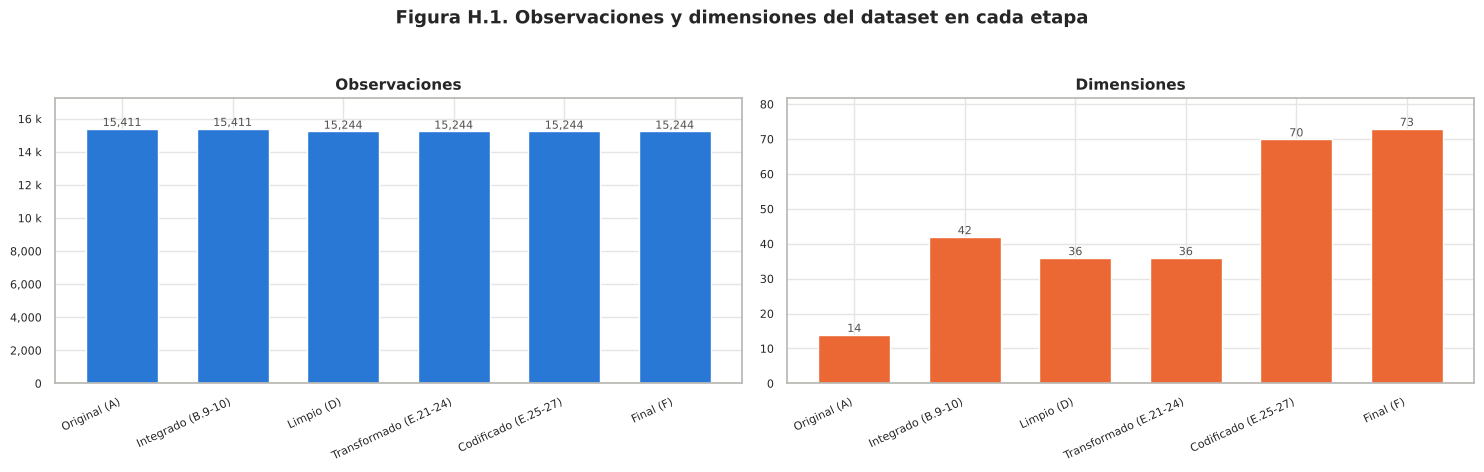

In [22]:
# =====================================================================
# Propósito: resumir observaciones, dimensiones, nulos y duplicados de
#            cada etapa del proceso.
# Entrada:   etapas.
# Salida:    tabla resumen_etapas y Figura H.1
#            (figuras/figura_H1_evolucion_etapas.png).
# =====================================================================
filas = []
for nombre, datos in etapas.items():
    sin_indice = datos.drop(columns=["Indice_Original"], errors="ignore")
    filas.append({"Etapa": nombre, "Observaciones": len(datos), "Dimensiones": datos.shape[1],
                  "Nulos totales": int(datos.isna().sum().sum()),
                  "Registros con algún nulo": int(datos.isna().any(axis=1).sum()),
                  "Duplicados (sin índice)": int(sin_indice.duplicated().sum())})
resumen_etapas = pd.DataFrame(filas).set_index("Etapa")
display(resumen_etapas)

graficar_etapas(resumen_etapas, "Figura H.1. Observaciones y dimensiones del dataset en cada etapa",
                "figura_H1_evolucion_etapas.png")
plt.show()

### Resultado H.1
- **Observaciones:** solo cambian en la limpieza (D), de 15,411 a 15,244, al eliminar 167 duplicados; se conserva el 98.9 % de los registros. La integración (B.9) conservó los 15,411 porque UCI se resumió a una fila por fabricante, lo que dejó una relación muchos a uno. Los filtros de la Sección C se aplicaron sobre copias para medir su efecto y no se trasladaron al dataset: la Sección D parte directamente del archivo integrado.
- **Dimensiones:** pasan de 14 a 42 en la integración (`Año`, `Marca`, `Marca_Homologada` y 25 dimensiones de UCI), bajan a 36 en la limpieza (se eliminan 7 y se agrega `Tiene_Datos_UCI`), suben a 70 con la codificación y a 73 con las tres características nuevas.
- **Nulos:** la integración generó 273,793 nulos en 11,433 registros (74.2 %). De ellos, 10,887 son de marcas sin correspondencia en UCI y 546 de Renault e Isuzu, cuyos datos en UCI estaban incompletos. La Sección D los imputó (mediana en las cuantitativas y "Desconocido" en las cualitativas) y desde entonces no hay nulos.
- **Duplicados:** los 167 del dataset original se eliminan en D. El redondeo del inciso 24 deja 6 registros idénticos que antes solo se distinguían por decimales (observación 9); no son anuncios repetidos del original.

## H.2 Calidad de los datos al inicio y al final

**¿Qué hace esta celda?** Compara indicadores de calidad entre CarDekho original y el dataset final: nulos, duplicados, clases de marca, nombre y modelo, valores extremos y tipos de dato.
**¿Para qué?** Para comprobar si se resolvieron los problemas identificados en el EDA inicial (Sección A y observaciones 4 a 8).

In [23]:
# =====================================================================
# Propósito: comparar indicadores de calidad entre los datos originales
#            de CarDekho y el dataset final.
# Entrada:   cd_ini, etapas["Integrado (B.9-10)"] y df.
# Salida:    tabla calidad.
# =====================================================================
integrado = etapas["Integrado (B.9-10)"]
indicadores = {
    "Nulos (CarDekho original / dataset final)": (cd_ini.isna().sum().sum(), df.isna().sum().sum()),
    "Registros con nulos tras integrar / al final": (integrado.isna().any(axis=1).sum(), df.isna().any(axis=1).sum()),
    "Registros duplicados (sin índice)": (cd_ini.drop(columns="Indice_Original").duplicated().sum(),
                                          df.duplicated().sum()),
    "Clases de marca (Marca_Original / Marca)": (cd_ini["Marca_Original"].nunique(), df["Marca"].nunique()),
    "Clases de Nombre": (cd_ini["Nombre"].nunique(), df["Nombre"].nunique()),
    "Clases de Modelo": (cd_ini["Modelo"].nunique(), df["Modelo"].nunique()),
    "Registros con Asientos = 0": ((cd_ini["Asientos"] == 0).sum(), (df["Asientos"] == 0).sum()),
    "Kilómetros máximo": (cd_ini["Kilómetros"].max(), df["Kilómetros"].max()),
    "Dimensiones guardadas como texto": (cd_ini.select_dtypes(exclude="number").shape[1],
                                         df.select_dtypes(exclude="number").shape[1]),
    "Dimensiones numéricas": (cd_ini.select_dtypes("number").shape[1], df.select_dtypes("number").shape[1]),
}
calidad = pd.DataFrame(indicadores, index=["Inicial", "Final"]).T.astype("int64")
calidad["Diferencia"] = calidad["Final"] - calidad["Inicial"]
display(calidad)

print("Tipo de dato de las dimensiones redondeadas en el inciso 24:")
display(pd.DataFrame({"Inicial": cd_ini[["Millaje", "Motor", "Potencia_Máxima"]].dtypes.astype(str),
                      "Final": df[["Millaje", "Motor", "Potencia_Máxima"]].dtypes.astype(str)}))

,Inicial,Final,Diferencia
Nulos (CarDekho original / dataset final),0,0,0
Registros con nulos tras integrar / al final,11433,0,-11433
Registros duplicados (sin índice),167,6,-161
Clases de marca (Marca_Original / Marca),32,30,-2
Clases de Nombre,121,120,-1
Clases de Modelo,120,120,0
Registros con Asientos = 0,2,2,0
Kilómetros máximo,3800000,3800000,0
Dimensiones guardadas como texto,6,13,7
Dimensiones numéricas,8,60,52


Tipo de dato de las dimensiones redondeadas en el inciso 24:


,Inicial,Final
Millaje,float64,int64
Motor,int64,int64
Potencia_Máxima,float64,int64


### Resultado H.2
- **Problemas resueltos:** los nulos que generó la integración (de 11,433 registros a 0), los duplicados (de 167 a 6, y esos 6 los generó el redondeo), las marcas (de 32 a 30 clases, al unir ISUZU y Mercedes-AMG) y `Nombre` (de 121 a 120). `Millaje` y `Potencia_Máxima` pasaron de `float64` a `int64`; `Motor` ya era `int64`.
- **Problemas que persisten:** los 2 registros con `Asientos = 0`, el máximo de 3,800,000 km y las variantes de escritura de `Modelo` (RediGO / redi-GO y los nombres truncados; `Modelo` sigue con 120 clases). Ninguna etapa los trató, así que siguen afectando los mínimos, los máximos y la asimetría de esas dimensiones.
- **Tipos de dimensión:** el dataset final tiene 13 dimensiones de texto (antes 6) por `Marca`, `Marca_Homologada` y las 6 categóricas de UCI que se conservaron, y 60 numéricas (antes 8) por las dimensiones de UCI, las codificadas y las nuevas.

## H.3 Estadísticos de las dimensiones de CarDekho

**¿Qué hace esta celda?** Compara la media, la mediana, la desviación, el mínimo y el máximo de cada cuantitativa de CarDekho al inicio y al final, con su diferencia y su cambio porcentual. `Edad_Vehiculo` se compara con `Antigüedad`, que la reemplaza en el dataset final (2021 − `Año`).

In [24]:
# =====================================================================
# Propósito: comparar media, mediana, desviación, mínimo y máximo de las
#            dimensiones de CarDekho al inicio y al final.
# Entrada:   cd_ini y df.
# Salida:    tabla comparacion_cd.
# =====================================================================
PARES_CD = [("Kilómetros", "Kilómetros"), ("Millaje", "Millaje"), ("Motor", "Motor"),
            ("Potencia_Máxima", "Potencia_Máxima"), ("Asientos", "Asientos"),
            ("Precio_Venta", "Precio_Venta"), ("Edad_Vehiculo", "Antigüedad")]
est_ini_cd = estadisticos_cuantitativos(cd_ini, [a for a, _ in PARES_CD])
est_fin_cd = estadisticos_cuantitativos(df, [d for _, d in PARES_CD])
comparacion_cd = comparar_estadisticos(est_ini_cd, est_fin_cd, PARES_CD)
comparacion_cd

Antes        Después  Diferencia  Cambio %
Dimensión                  Medida                                                            
Kilómetros                 Observaciones      15,411.000     15,244.000    -167.000    -1.084
                           Media              55,616.481     55,639.582      23.102     0.042
                           Mediana            50,000.000     50,000.000       0.000     0.000
                           Desv. estándar     51,618.548     51,766.299     147.751     0.286
                           Mínimo                100.000        100.000       0.000     0.000
                           Máximo          3,800,000.000  3,800,000.000       0.000     0.000
Millaje                    Observaciones      15,411.000     15,244.000    -167.000    -1.084
                           Media                  19.701         19.718       0.016     0.083
                           Mediana                19.670         20.000       0.330     1.678
                           Desv. estándar          4.171          4.154      -0.017    -0.418
                           Mínimo                  4.000          4.000       0.000     0.000
                           Máximo                 33.540         34.000       0.460     1.371
Motor                      Observaciones      15,411.000     15,244.000    -167.000    -1.084
                           Media               1,486.058      1,486.172       0.114     0.008
                           Mediana             1,248.000      1,248.000       0.000     0.000
                           Desv. estándar        521.107        520.419      -0.687    -0.132
                           Mínimo                793.000        793.000       0.000     0.000
                           Máximo              6,592.000      6,592.000       0.000     0.000
Potencia_Máxima            Observaciones      15,411.000     15,244.000    -167.000    -1.084
                           Media                 100.588        100.611       0.023     0.023
                           Mediana                88.500         88.000      -0.500    -0.565
                           Desv. estándar         42.973         42.920      -0.053    -0.124
                           Mínimo                 38.400         38.000      -0.400    -1.042
                           Máximo                626.000        626.000       0.000     0.000
Asientos                   Observaciones      15,411.000     15,244.000    -167.000    -1.084
                           Media                   5.325          5.326       0.001     0.013
                           Mediana                 5.000          5.000       0.000     0.000
                           Desv. estándar          0.808          0.809       0.001     0.140
                           Mínimo                  0.000          0.000       0.000       NaN
                           Máximo                  9.000          9.000       0.000     0.000
Precio_Venta               Observaciones      15,411.000     15,244.000    -167.000    -1.084
                           Media             774,971.116    774,701.448    -269.668    -0.035
                           Mediana           556,000.000    559,000.000   3,000.000     0.540
                           Desv. estándar    894,128.363    894,676.082     547.719     0.061
                           Mínimo             40,000.000     40,000.000       0.000     0.000
                           Máximo         39,500,000.000 39,500,000.000       0.000     0.000
Edad_Vehiculo → Antigüedad Observaciones      15,411.000     15,244.000    -167.000    -1.084
                           Media                   6.036          6.041       0.005     0.079
                           Mediana                 6.000          6.000       0.000     0.000
                           Desv. estándar          3.013          3.016       0.003     0.097
                           Mínimo                  0.000          0.000       0.000       NaN
         

### Resultado H.3
- Las dimensiones de CarDekho casi no cambiaron: ninguna media varió más de 0.1 % ni ninguna desviación estándar más de 0.5 %, y los mínimos y máximos son los mismos, salvo el efecto del redondeo.
- **Causas de las diferencias:** la eliminación de 167 duplicados (1.1 % de los registros) mueve ligeramente la mediana de `Precio_Venta` (de 556,000 a 559,000 INR), y el redondeo del inciso 24 cambia la mediana de `Millaje` (de 19.67 a 20) y de `Potencia_Máxima` (de 88.5 a 88).
- `Antigüedad` reproduce a `Edad_Vehiculo` porque ambas usan 2021 como año de referencia. El proceso conservó la información original de CarDekho.

## H.4 Dimensiones de UCI antes y después de la integración

**Antes de leer esta comparación:** el UCI original (205 modelos vendidos en EE. UU. en 1985) y el dataset final (15,244 anuncios de autos usados en India en 2021) no son la misma población. Por eso esta sección no mide cómo cambiaron los vehículos, sino **cómo cambió la representación de la información de UCI** al resumirla por fabricante, imputarla e integrarla con CarDekho.

**¿Qué hace esta celda?** Compara la media, la desviación y los valores distintos de cada dimensión de UCI en su forma original y en el dataset final.
- Para que la comparación sea válida, los valores originales se convierten a las mismas unidades métricas que usó la Sección E (inciso 23): mpg a km/l (× 0.425144), in³ a cc (× 16.387064), pulgadas a mm (× 25.4) y libras a kg (× 0.453592).
- El dataset final se describe de dos formas: solo con los registros que tienen datos reales de UCI y con todos los registros (incluye los imputados con la mediana).

In [25]:
# =====================================================================
# Propósito: comparar media, desviación y valores distintos de las
#            dimensiones de UCI: original (en unidades métricas) contra
#            el dataset final.
# Entrada:   uci_ini y df.
# Salida:    tabla comparacion_uci.
# =====================================================================
# Factores de la Sección E (inciso 23): mpg -> km/l, in³ -> cc, in -> mm, lb -> kg.
CONVERSION = {"MPG_Ciudad": ("Millaje_Ciudad", 0.425144), "MPG_Carretera": ("Millaje_Carretera", 0.425144),
              "Caballos_Fuerza": ("Caballos_Fuerza", 1), "RPM_Maximas": ("RPM_Maximas", 1),
              "Tamano_Motor": ("Tamano_Motor", 16.387064), "Num_Cilindros": ("Num_Cilindros", 1),
              "Peso_Vacio": ("Peso_Vacio", 0.453592), "Longitud": ("Longitud", 25.4),
              "Ancho": ("Ancho", 25.4), "Altura": ("Altura", 25.4), "Distancia_Ejes": ("Distancia_Ejes", 25.4),
              "Diametro_Cilindro": ("Diametro_Cilindro", 25.4), "Carrera_Piston": ("Carrera_Piston", 25.4),
              "Relacion_Compresion": ("Relacion_Compresion", 1), "Num_Puertas": ("Num_Puertas", 1)}
uci_metrico = pd.DataFrame({final: pd.to_numeric(uci_ini[orig], errors="coerce") * factor
                            for orig, (final, factor) in CONVERSION.items()})
con_uci = df[df["Tiene_Datos_UCI"] == 1]

filas = []
for col in uci_metrico.columns:
    filas.append({"Dimensión": col,
                  "Media original": uci_metrico[col].mean(),
                  "Media final (con UCI)": con_uci[col].mean(),
                  "Media final (todos)": df[col].mean(),
                  "Desv. original": uci_metrico[col].std(),
                  "Desv. final (con UCI)": con_uci[col].std(),
                  "Desv. final (todos)": df[col].std(),
                  "Valores distintos original": uci_metrico[col].nunique(),
                  "Valores distintos final": df[col].nunique()})
comparacion_uci = pd.DataFrame(filas).set_index("Dimensión")
comparacion_uci["Reducción de la desv. (todos) %"] = (
    1 - comparacion_uci["Desv. final (todos)"] / comparacion_uci["Desv. original"]) * 100
comparacion_uci

,Media original,Media final (con UCI),Media final (todos),Desv. original,Desv. final (con UCI),Desv. final (todos),Valores distintos original,Valores distintos final,Reducción de la desv. (todos) %
Dimensión,,,,,,,,,
Millaje_Ciudad,10.722,11.056,11.504,2.781,1.975,1.109,29,12,60.116
Millaje_Carretera,13.074,13.420,13.822,2.928,2.076,1.155,30,12,60.533
Caballos_Fuerza,104.256,97.469,85.903,39.714,27.395,16.627,59,11,58.133
RPM_Maximas,"5,125.369","5,256.019","5,184.126",479.335,406.721,225.400,23,11,52.977
Tamano_Motor,"2,079.638","2,098.228","1,991.475",682.401,642.011,354.925,44,12,47.989
Num_Cilindros,4.380,4.488,4.202,1.081,0.846,0.494,7,10,54.257
Peso_Vacio,"1,159.184","1,135.894","1,115.684",236.176,211.773,115.586,171,12,51.060
Longitud,"4,420.851","4,394.706","4,375.244",313.367,275.137,149.738,75,12,52.216
Ancho,"1,674.058","1,674.248","1,659.463",54.488,47.712,27.579,44,12,49.385


### Resultado H.4
- Las dimensiones de UCI son las que más cambiaron. Con todos los registros, su desviación estándar es entre 48 % y 86 % menor que en los 205 vehículos originales; con solo los registros que tienen datos de UCI, es entre 6 % y 75 % menor. Los valores distintos bajan de decenas a 12 o menos (por ejemplo, `Caballos_Fuerza` pasa de 59 a 11).
- **Causas:**
  - La integración resumió UCI a un promedio por fabricante (B.9), con lo que se pierde la variación entre modelos de un mismo fabricante.
  - La limpieza imputó con la mediana al 70.6 % de los registros (D.15), que reciben todos el mismo valor.
  - En el dataset final cada fabricante pesa según su número de anuncios en CarDekho y no según su número de modelos en UCI; por eso también cambian las medias.
- `Num_Puertas` y `Num_Cilindros` tienen ahora valores no enteros (por ejemplo, 3.125 puertas), porque son promedios: ya no describen un vehículo real.
- **Alcance:** como las dos fuentes describen poblaciones distintas, la comparación es aproximada. Lo que muestra con claridad, en las 15 dimensiones, es la pérdida de variabilidad que produjo el procesamiento, no un cambio en los vehículos.

## H.5 Clases de las dimensiones cualitativas

**¿Qué hace esta celda?** Compara la cantidad y el porcentaje de observaciones por clase al inicio y al final. En `Marca` solo muestra las clases que cambiaron. Para las categóricas de UCI, el inicio son los 205 vehículos de UCI y el final los 15,244 registros integrados.

In [26]:
# =====================================================================
# Propósito: comparar clases de CarDekho y de UCI al inicio y al final.
# Entrada:   cd_ini, uci_ini y df.
# Salida:    una tabla de comparación por dimensión.
# =====================================================================
for col in ["Combustible", "Transmisión", "Tipo_Vendedor"]:
    print(f"\n{col}")
    display(comparar_clases(cd_ini[col], df[col]))

print("\nMarca (Marca_Original al inicio, Marca al final): solo las clases que cambiaron")
marcas = comparar_clases(cd_ini["Marca_Original"].rename("Marca"), df["Marca"])
display(marcas[(marcas["Obs. antes"] == 0) | (marcas["Obs. después"] == 0)])

for col in ["Carroceria", "Traccion", "Tipo_Motor"]:
    print(f"\n{col} (UCI original vs dataset final)")
    display(comparar_clases(uci_ini[col], df[col]))


Combustible


,Obs. antes,% antes,Obs. después,% después,Diferencia (pp)
Combustible,,,,,
Petrol,7643,49.594,7555,49.560,-0.034
Diesel,7419,48.141,7342,48.163,0.022
CNG,301,1.953,299,1.961,0.008
LPG,44,0.286,44,0.289,0.003
Electric,4,0.026,4,0.026,0.000



Transmisión


,Obs. antes,% antes,Obs. después,% después,Diferencia (pp)
Transmisión,,,,,
Manual,12225,79.326,12094,79.336,0.010
Automatic,3186,20.674,3150,20.664,-0.010



Tipo_Vendedor


...

,Obs. antes,% antes,Obs. después,% después,Diferencia (pp)
Carroceria,,,,,
Desconocido,0,0.000,10760,70.585,70.585
hatchback,70,34.146,2792,18.315,-15.831
sedan,96,46.829,1671,10.962,-35.868
hardtop,8,3.902,21,0.138,-3.765
convertible,6,2.927,0,0.000,-2.927
wagon,25,12.195,0,0.000,-12.195



Traccion (UCI original vs dataset final)


,Obs. antes,% antes,Obs. después,% después,Diferencia (pp)
Traccion,,,,,
Desconocido,0,0.000,10760,70.585,70.585
fwd,120,58.537,3616,23.721,-34.816
rwd,76,37.073,868,5.694,-31.379
4wd,9,4.390,0,0.000,-4.390



Tipo_Motor (UCI original vs dataset final)


,Obs. antes,% antes,Obs. después,% después,Diferencia (pp)
Tipo_Motor,,,,,
Desconocido,0,0.000,10760,70.585,70.585
ohc,148,72.195,4405,28.897,-43.299
dohc,12,5.854,58,0.380,-5.473
ohcf,15,7.317,21,0.138,-7.179
l,12,5.854,0,0.000,-5.854
dohcv,1,0.488,0,0.000,-0.488
ohcv,13,6.341,0,0.000,-6.341
rotor,4,1.951,0,0.000,-1.951


### Resultado H.5
- **Categóricas de CarDekho:** los porcentajes cambian menos de 0.2 puntos porcentuales, porque la eliminación de duplicados afectó de forma pareja a todas las clases. En `Marca` desaparecen ISUZU y Mercedes-AMG, que se unieron a Isuzu y Mercedes-Benz.
- **Categóricas de UCI:** aparece Desconocido con el 70.6 % y se pierden clases (convertible, wagon, 4wd, ohcv, rotor, entre otras). La causa es que la integración tomó la moda por fabricante: cada marca conserva solo su clase más frecuente, así que la variedad de UCI se reduce a una clase por fabricante.

## H.6 Distribución del precio

**¿Qué hace esta celda?** Compara la forma de la distribución del precio y de otras dimensiones sesgadas al inicio y al final, y dibuja la Figura H.2.
- La **asimetría** vale 0 en una distribución simétrica.
- La **curtosis** (exceso) vale 0 en una distribución normal y crece con la cantidad de valores extremos.

,Asimetría,Curtosis,Media,Mediana
Precio_Venta (inicial),10.047,281.981,"774,971.116","556,000.000"
Precio_Venta (final),10.109,284.282,"774,701.448","559,000.000"
Precio_Venta_Log (final),0.564,1.472,13.279,13.234
Kilómetros (inicial),28.173,"1,846.527","55,616.481","50,000.000"
Kilómetros (final),28.229,"1,845.455","55,639.582","50,000.000"
Precio_por_Km (final),35.992,"2,037.657",32.850,11.821


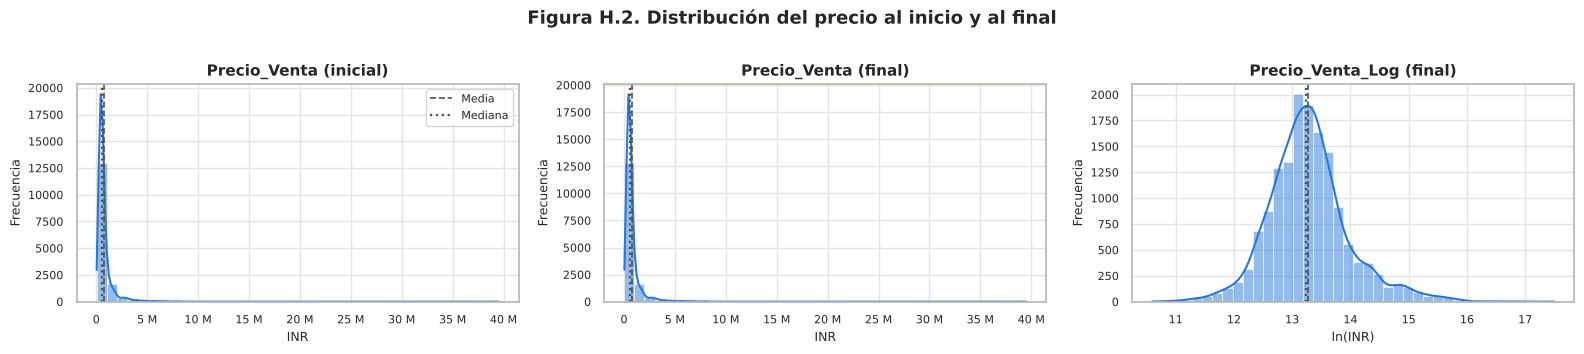

In [27]:
# =====================================================================
# Propósito: comparar asimetría y curtosis del precio y de otras
#            dimensiones sesgadas, y graficar el precio antes y después.
# Entrada:   cd_ini y df.
# Salida:    tabla forma y Figura H.2 (figuras/figura_H2_precio_antes_despues.png).
# =====================================================================
series = {"Precio_Venta (inicial)": cd_ini["Precio_Venta"],
          "Precio_Venta (final)": df["Precio_Venta"],
          "Precio_Venta_Log (final)": df["Precio_Venta_Log"],
          "Kilómetros (inicial)": cd_ini["Kilómetros"],
          "Kilómetros (final)": df["Kilómetros"],
          "Precio_por_Km (final)": df["Precio_por_Km"]}
forma = pd.DataFrame({"Asimetría": {k: s.skew() for k, s in series.items()},
                      "Curtosis": {k: s.kurt() for k, s in series.items()},
                      "Media": {k: s.mean() for k, s in series.items()},
                      "Mediana": {k: s.median() for k, s in series.items()}})
display(forma)

# Series de distinta longitud en una sola tabla; cada panel ignora sus NaN.
precios = pd.concat([series[k].reset_index(drop=True).rename(k)
                     for k in ["Precio_Venta (inicial)", "Precio_Venta (final)", "Precio_Venta_Log (final)"]], axis=1)
graficar_distribuciones_cuantitativas(
    precios, list(precios.columns),
    {"Precio_Venta (inicial)": "INR", "Precio_Venta (final)": "INR", "Precio_Venta_Log (final)": "ln(INR)"},
    "Figura H.2. Distribución del precio al inicio y al final", "figura_H2_precio_antes_despues.png")
plt.show()

### Resultado H.6
- La forma de `Precio_Venta` no cambió (asimetría de 10.05 al inicio y 10.11 al final; curtosis de 282 y 284), porque las etapas B a D no modifican los precios; la diferencia se debe a la eliminación de duplicados.
- La transformación logarítmica del inciso 25 es el cambio de mayor efecto en la forma: `Precio_Venta_Log` tiene asimetría de 0.56 y curtosis de 1.47, mucho más cercanas a 0 (distribución simétrica y sin colas pesadas) que las del precio original (Figura H.2).
- `Kilómetros` conserva su asimetría (28.2) porque su valor extremo no se trató. `Precio_por_Km` (36.0) resulta aún más asimétrica que el precio, porque divide entre kilómetros que pueden ser muy pequeños.

## H.7 Correlaciones con el precio

**¿Qué hace esta celda?** Compara la correlación de Pearson de cada dimensión con el precio al inicio y al final, y dibuja la Figura H.3. Para las dimensiones de UCI, la columna inicial es su correlación con el precio de UCI (USD de 1985), porque al inicio no estaban unidas a CarDekho.

,Inicial: con su propio precio,Final: Precio_Venta,Final: Precio_Venta_Log
Potencia_Máxima,0.750,0.751,0.759
Motor,0.586,0.586,0.654
Millaje,-0.306,-0.307,-0.305
Kilómetros,-0.080,-0.080,-0.095
Asientos,0.115,0.115,0.231
Antigüedad (Edad_Vehiculo),-0.242,-0.241,-0.486
Precio_por_Km (nueva),NaN,0.597,0.299
Vehiculo_Antiguo (nueva),NaN,-0.170,-0.395
Caballos_Fuerza (UCI),0.811,0.566,0.534
Tamano_Motor (UCI),0.872,0.452,0.405


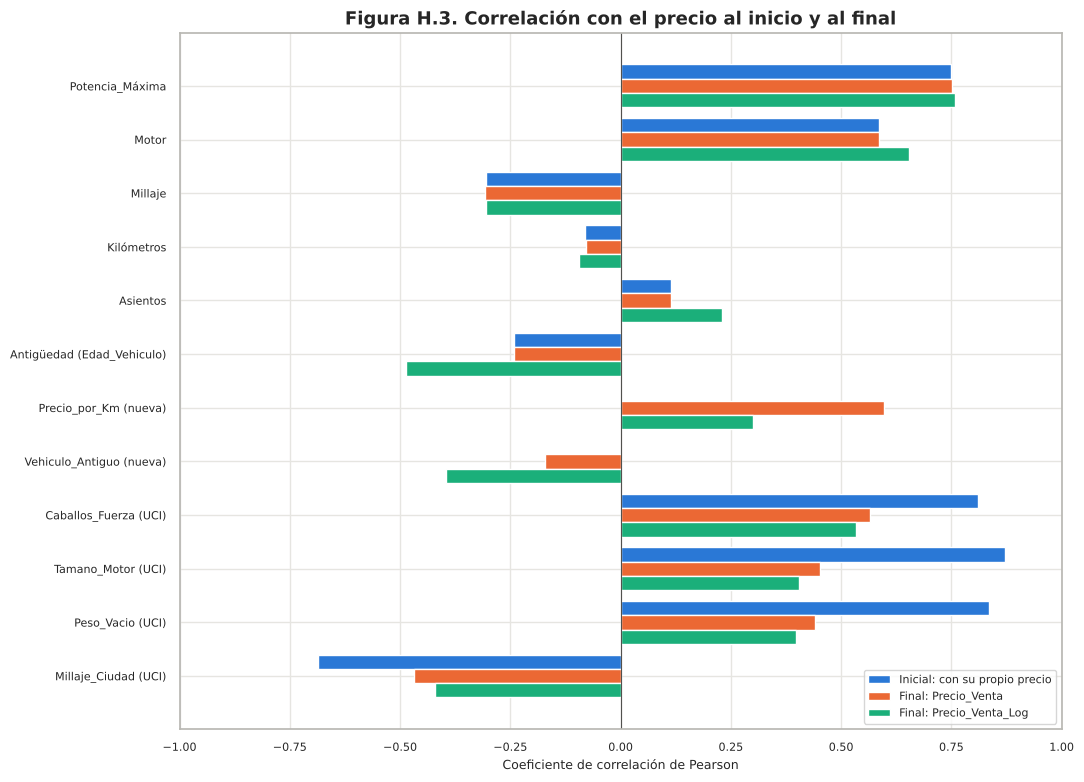

In [28]:
# =====================================================================
# Propósito: tabla y gráfica de correlaciones con el precio al inicio
#            (CarDekho y UCI por separado) y al final.
# Entrada:   cd_ini, uci_ini y df.
# Salida:    tabla correlaciones y Figura H.3
#            (figuras/figura_H3_correlaciones_antes_despues.png).
# =====================================================================
# Nombre en la tabla -> (columna inicial, dataset inicial, columna final)
FILAS = {"Potencia_Máxima": ("Potencia_Máxima", "cd", "Potencia_Máxima"),
         "Motor": ("Motor", "cd", "Motor"),
         "Millaje": ("Millaje", "cd", "Millaje"),
         "Kilómetros": ("Kilómetros", "cd", "Kilómetros"),
         "Asientos": ("Asientos", "cd", "Asientos"),
         "Antigüedad (Edad_Vehiculo)": ("Edad_Vehiculo", "cd", "Antigüedad"),
         "Precio_por_Km (nueva)": (None, None, "Precio_por_Km"),
         "Vehiculo_Antiguo (nueva)": (None, None, "Vehiculo_Antiguo"),
         "Caballos_Fuerza (UCI)": ("Caballos_Fuerza", "uci", "Caballos_Fuerza"),
         "Tamano_Motor (UCI)": ("Tamano_Motor", "uci", "Tamano_Motor"),
         "Peso_Vacio (UCI)": ("Peso_Vacio", "uci", "Peso_Vacio"),
         "Millaje_Ciudad (UCI)": ("MPG_Ciudad", "uci", "Millaje_Ciudad")}
filas = {}
for nombre, (col_ini, origen, col_fin) in FILAS.items():
    inicial = None
    if origen == "cd":
        inicial = cd_ini[col_ini].corr(cd_ini["Precio_Venta"])
    elif origen == "uci":
        inicial = uci_ini[col_ini].corr(uci_ini["Precio"])
    filas[nombre] = {"Inicial: con su propio precio": inicial,
                     "Final: Precio_Venta": df[col_fin].corr(df["Precio_Venta"]),
                     "Final: Precio_Venta_Log": df[col_fin].corr(df["Precio_Venta_Log"])}
correlaciones = pd.DataFrame(filas).T.astype("float64")
display(correlaciones)

graficar_comparacion_correlaciones(correlaciones,
                                   "Figura H.3. Correlación con el precio al inicio y al final",
                                   "figura_H3_correlaciones_antes_despues.png")
plt.show()

### Resultado H.7
- **CarDekho:** con `Precio_Venta`, las correlaciones son prácticamente las mismas que al inicio (diferencias menores a 0.002). Con `Precio_Venta_Log` algunas aumentan: `Antigüedad` pasa de −0.24 a −0.49, `Motor` de 0.59 a 0.65 y `Asientos` de 0.12 a 0.23. La correlación de Pearson mide relaciones lineales; en escala logarítmica estas relaciones son más cercanas a una línea y los precios extremos pesan menos.
- **UCI:** sus dimensiones pierden fuerza. `Caballos_Fuerza`, `Tamano_Motor` y `Peso_Vacio` tenían correlaciones de 0.81 a 0.87 con el precio de UCI y tienen de 0.44 a 0.57 con `Precio_Venta` (de 0.40 a 0.53 con su logaritmo); `Millaje_Ciudad` pasa de −0.69 a −0.47. Además de ser promedios por fabricante con imputación, ahora se comparan con precios de otro país, otra época y de autos usados.
- **Nuevas:** `Vehiculo_Antiguo` tiene −0.40 con el logaritmo del precio. `Precio_por_Km` tiene 0.60 con `Precio_Venta`, en parte porque el precio está en su numerador; con el logaritmo baja a 0.30.

## H.8 Aporte de las dimensiones nuevas

**¿Qué hace esta celda?** Reúne en una tabla los indicadores de las dimensiones creadas en las Secciones B y F (`Marca`, `Modelo`, `Antigüedad`, `Vehiculo_Antiguo` y `Precio_por_Km`), con los resultados de la Sección G.
**¿Para qué?** Para resumir qué información agrega cada una al análisis.

In [29]:
# =====================================================================
# Propósito: indicadores de las dimensiones nuevas: clases de Marca y
#            Modelo, relación de Antigüedad y Vehiculo_Antiguo con el
#            precio y valores típicos de Precio_por_Km.
# Entrada:   df.
# Salida:    tabla aporte.
# =====================================================================
mediana_grupo = df.groupby("Vehiculo_Antiguo")["Precio_Venta"].median()
aporte = pd.DataFrame({
    "Marca: clases": df["Marca"].nunique(),
    "Modelo: clases": df["Modelo"].nunique(),
    "Antigüedad: correlación con Precio_Venta_Log": df["Antigüedad"].corr(df["Precio_Venta_Log"]),
    "Vehiculo_Antiguo: % de vehículos antiguos": df["Vehiculo_Antiguo"].mean() * 100,
    "Vehiculo_Antiguo: precio mediano no antiguos (INR)": mediana_grupo[0],
    "Vehiculo_Antiguo: precio mediano antiguos (INR)": mediana_grupo[1],
    "Precio_por_Km: mediana (INR/km)": df["Precio_por_Km"].median(),
    "Precio_por_Km: máximo (INR/km)": df["Precio_por_Km"].max(),
}, index=["Valor"]).T
aporte

,Valor
Marca: clases,30.000
Modelo: clases,120.000
Antigüedad: correlación con Precio_Venta_Log,-0.486
Vehiculo_Antiguo: % de vehículos antiguos,13.494
Vehiculo_Antiguo: precio mediano no antiguos (INR),"600,000.000"
Vehiculo_Antiguo: precio mediano antiguos (INR),"275,000.000"
Precio_por_Km: mediana (INR/km),11.821
Precio_por_Km: máximo (INR/km),"10,394.737"


### Resultado H.8
- `Marca` (30 clases) y `Modelo` (120) permiten analizar el precio por fabricante y por vehículo; `Marca` además fue la base de la clave de integración.
- `Antigüedad` tiene −0.49 con el logaritmo del precio. Sin contar `Año`, que contiene la misma información, es la dimensión de CarDekho con mayor correlación con el logaritmo del precio después de `Potencia_Máxima` (0.76) y `Motor` (0.65).
- `Vehiculo_Antiguo` resume esa información en dos grupos con precios medianos muy distintos (600,000 contra 275,000 INR).
- `Precio_por_Km` (mediana de 11.82 INR/km) expresa el valor por kilómetro recorrido, pero sus valores extremos obligan a analizarla con la mediana o en escala logarítmica.

## H.9 Conclusiones
1. **El proceso conservó la información de CarDekho y mejoró su calidad.** Se mantuvo el 98.9 % de los registros; las medias y desviaciones de las dimensiones originales cambiaron menos de 0.5 % y sus correlaciones con el precio menos de 0.002. Al mismo tiempo se trataron los nulos que generó la integración, se eliminaron los 167 duplicados, se homologaron las marcas y las medidas quedaron como enteros.
2. **El cambio más grande fue de estructura.** El dataset pasó de 14 a 73 dimensiones. De ellas, 32 (44 %) son códigos de la Sección E que permiten usar las categorías en análisis numéricos; no son medidas nuevas.
3. **La información de UCI aporta poco a nivel de vehículo.** Solo el 29.4 % de los registros tiene datos reales, y son promedios por fabricante. Su variabilidad bajó entre 48 % y 86 %, y la correlación de sus principales medidas con el precio pasó de 0.81–0.87 (con el precio de UCI) a 0.44–0.57 (con `Precio_Venta`). Estas dimensiones deben interpretarse como características del fabricante, no del auto, y sus categóricas funcionan como sustitutos de la marca.
4. **La transformación logarítmica del precio fue el cambio con mayor efecto en el análisis.** Redujo la asimetría de 10.11 a 0.56 y aumentó la correlación del precio con la antigüedad (de −0.24 a −0.49) y con el motor (de 0.59 a 0.65).
5. **Las características nuevas aportan información a nivel de vehículo.** La correlación de `Antigüedad` con el logaritmo del precio (−0.49) es de magnitud comparable a la de `Caballos_Fuerza` de UCI (0.53), pero `Antigüedad` describe a cada auto y está disponible en el 100 % de los registros. `Vehiculo_Antiguo` separa dos grupos con precios medianos de 600,000 y 275,000 INR. `Precio_por_Km` resume el valor por uso, pero es muy asimétrica (36.0) y conviene describirla con su mediana (11.82 INR/km).
6. **Quedan pendientes para un análisis posterior** los 2 registros con `Asientos = 0`, el vehículo con 3,800,000 km, las variantes de escritura de `Modelo` y los 6 registros idénticos que dejó el redondeo. No cambian las conclusiones anteriores, pero sí los mínimos, los máximos y la asimetría de esas dimensiones.

Las correlaciones de esta sección describen asociaciones lineales entre dimensiones; no demuestran que una dimensión cause el precio.